<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/15min/04_Intraday_MLP_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Final Enhanced Intraday MLP

This is the **final MLP notebook** for the intraday volatility-forecasting branch.

It trains both:

1. **Asset-Specific MLPs** — one model each for BTC, ETH, SOL and XRP.
2. **Global MLP** — one pooled model trained jointly on all four assets with explicit asset identity.

The target remains next-candle squared log return:
\[
RV_{t+1}=r_{t+1}^{2}.
\]

The final formulation improves volatility forecasting through direct QLIKE-aligned training, training-only intraday deseasonalization, multi-scale volatility-state features, range estimators, semivariance, activity/order-flow features, and a residual dense architecture.

All time horizons are expressed as durations. For example, `4h` becomes 16 bars with `15m` candles and 4 bars with `1h` candles.

Feature-set and learning-rate selection use an inner tuning window inside Train. Official Validation is evaluated only after the configuration is frozen. Test remains untouched.

## 1. Imports, reproducibility and Drive

In [1]:
from google.colab import drive

from pathlib import Path
from datetime import datetime, timezone
import gc
import importlib.metadata
import json
import math
import os
import random
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    Add,
    Activation,
    Concatenate,
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)
from tensorflow.keras.initializers import Constant

drive.mount("/content/drive")

BASE_SEED = 42

os.environ["PYTHONHASHSEED"] = str(BASE_SEED)
random.seed(BASE_SEED)
np.random.seed(BASE_SEED)
tf.keras.utils.set_random_seed(BASE_SEED)

try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow deterministic operations enabled.")
except Exception as error:
    print("Deterministic-op request unavailable:", error)

print("TensorFlow:", tf.__version__)
print("scikit-learn:", importlib.metadata.version("scikit-learn"))

Mounted at /content/drive
TensorFlow deterministic operations enabled.
TensorFlow: 2.20.0
scikit-learn: 1.6.1


## 2. Configuration

In [2]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Quant Research/15min"
)

# Change only after upstream Notebooks 01-04 have been run
# for the corresponding interval.
KLINE_INTERVAL = "15m"

SYMBOLS = [
    "BTCUSDT",
    "ETHUSDT",
    "SOLUSDT",
    "XRPUSDT",
]

EPSILON = 1e-12

# ------------------------------------------------------------
# Inner development / tuning policy
# ------------------------------------------------------------

INNER_TUNING_DURATION = pd.Timedelta(days=180)

FEATURE_SET_CANDIDATES = [
    "HAR_STATE",
    "RANGE_SEMIVAR",
    "FULL_ACTIVITY",
]

LEARNING_RATE_CANDIDATES = [
    3e-4,
    1e-4,
]

# ------------------------------------------------------------
# Dynamic feature horizons
# ------------------------------------------------------------

RV_STATE_DURATIONS = [
    "30min",
    "1h",
    "2h",
    "4h",
    "8h",
    "12h",
    "1d",
]

RANGE_DURATIONS = [
    "1h",
    "4h",
    "1d",
]

SEMIVAR_DURATIONS = [
    "1h",
    "4h",
    "1d",
]

ACTIVITY_DURATIONS = [
    "4h",
    "1d",
]

LAG_DURATIONS = [
    "30min",
    "1h",
    "2h",
    "4h",
]

# ------------------------------------------------------------
# Network / optimizer
# ------------------------------------------------------------

BATCH_SIZE = 2048
MAX_INNER_EPOCHS = 80

EARLY_STOPPING_PATIENCE = 8
LR_PATIENCE = 3
MIN_LEARNING_RATE = 1e-6

WEIGHT_DECAY = 1e-5
CLIPNORM = 1.0

DROPOUT_1 = 0.08
DROPOUT_RESIDUAL = 0.05
DROPOUT_2 = 0.05

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

MANIFEST_ROOT = (
    PROJECT_ROOT
    / "manifests"
    / KLINE_INTERVAL
)

MODEL_READY_ROOT = (
    PROJECT_ROOT
    / "data"
    / "model_ready"
    / KLINE_INTERVAL
)

ARTIFACT_ROOT = (
    PROJECT_ROOT
    / "artifacts"
    / KLINE_INTERVAL
    / "MLP_FINAL"
)

MODEL_ROOT = (
    PROJECT_ROOT
    / "models"
    / KLINE_INTERVAL
    / "MLP_FINAL"
)

RESULTS_ROOT = (
    PROJECT_ROOT
    / "results"
    / KLINE_INTERVAL
    / "MLP_FINAL"
)

INNER_RESULTS_ROOT = (
    RESULTS_ROOT
    / "inner_tuning"
)

# ------------------------------------------------------------
# Dynamic visualization settings
# ------------------------------------------------------------
# Change to "12h", "4h", etc. without changing downstream code.
ROLLING_VOLATILITY_WINDOW = "1d"

# Number of calendar days/hours shown in forecast diagnostic figures.
PLOT_WINDOW_DURATION = "14d"

# None -> begin at Validation start.
# Or provide an explicit timezone-aware / UTC-compatible timestamp string.
PLOT_START = None

for directory in [
    MODEL_READY_ROOT,
    ARTIFACT_ROOT,
    MODEL_ROOT,
    RESULTS_ROOT,
    INNER_RESULTS_ROOT,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Project root:", PROJECT_ROOT)
print("Interval:", KLINE_INTERVAL)
print("Enhanced MLP results:", RESULTS_ROOT)

Project root: /content/drive/MyDrive/Quant Research/15min
Interval: 15m
Enhanced MLP results: /content/drive/MyDrive/Quant Research/15min/results/15m/MLP_FINAL


## 3. Load upstream manifests and datasets

Notebook 02 remains the canonical source for:

- interval length;
- split boundaries;
- target definition;
- processed returns;
- training-only full-Train seasonality factors.

Raw Notebook 01 OHLCV is loaded only to recover richer market-information fields that were not retained in the compact Notebook 02 output.

In [3]:
processing_manifest_candidates = sorted(
    MANIFEST_ROOT.glob(
        f"processing_manifest_{KLINE_INTERVAL}_v*.json"
    )
)

if len(processing_manifest_candidates) != 1:
    raise FileNotFoundError(
        "Expected exactly one Notebook 02 processing manifest "
        f"for {KLINE_INTERVAL}; found "
        f"{len(processing_manifest_candidates)}."
    )

PROCESSING_MANIFEST_PATH = (
    processing_manifest_candidates[0]
)

with open(
    PROCESSING_MANIFEST_PATH,
    "r",
    encoding="utf-8",
) as file:
    processing_manifest = json.load(file)

if (
    processing_manifest["kline_interval"]
    != KLINE_INTERVAL
):
    raise ValueError(
        "Processing-manifest interval mismatch."
    )

INTERVAL_MINUTES = int(
    processing_manifest["interval_minutes"]
)

INTERVAL_MS = int(
    processing_manifest["interval_ms"]
)

INTERVAL_DELTA = pd.Timedelta(
    minutes=INTERVAL_MINUTES
)

split_config = (
    processing_manifest[
        "split_boundaries_utc"
    ]
)

VALIDATION_START = pd.Timestamp(
    split_config[
        "validation_target_start"
    ]
)

TEST_START = pd.Timestamp(
    split_config[
        "validation_target_end_exclusive"
    ]
)

TEST_END_EXCLUSIVE = pd.Timestamp(
    split_config[
        "test_target_end_exclusive"
    ]
)

INNER_TUNE_START = (
    VALIDATION_START
    - INNER_TUNING_DURATION
)

TARGET_COLUMN = (
    processing_manifest["target_column"]
)

TARGET_VARIANCE_COLUMN = (
    processing_manifest[
        "target_variance_column"
    ]
)

FULL_FEATURES_PATH = Path(
    processing_manifest[
        "outputs"
    ][
        "full_features_parquet"
    ]
)

MODEL_ROWS_PATH = Path(
    processing_manifest[
        "outputs"
    ][
        "valid_model_rows_parquet"
    ]
)

FULL_TRAIN_SEASONALITY_PATH = Path(
    processing_manifest[
        "outputs"
    ][
        "seasonality_factors_parquet"
    ]
)

RAW_DATA_PATH = Path(
    processing_manifest[
        "source_raw_parquet"
    ]
)

for path in [
    FULL_FEATURES_PATH,
    MODEL_ROWS_PATH,
    FULL_TRAIN_SEASONALITY_PATH,
    RAW_DATA_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(
            f"Required upstream artifact not found:\n{path}"
        )

features_df = pd.read_parquet(
    FULL_FEATURES_PATH
)

canonical_model_rows_df = pd.read_parquet(
    MODEL_ROWS_PATH
)

full_train_seasonality_df = pd.read_parquet(
    FULL_TRAIN_SEASONALITY_PATH
)

raw_df = pd.read_parquet(
    RAW_DATA_PATH
)

for frame in [
    features_df,
    canonical_model_rows_df,
]:
    frame["open_time"] = pd.to_datetime(
        frame["open_time"],
        utc=True,
        errors="raise",
    )

    frame["target_open_time"] = pd.to_datetime(
        frame["target_open_time"],
        utc=True,
        errors="coerce",
    )

raw_df["open_time"] = pd.to_datetime(
    raw_df["open_time"],
    utc=True,
    errors="raise",
)

print("Interval minutes:", INTERVAL_MINUTES)
print("Inner tune start:", INNER_TUNE_START)
print("Official Validation start:", VALIDATION_START)
print("Official Test start:", TEST_START)
print("Full processed rows:", len(features_df))
print("Raw rows:", len(raw_df))

Interval minutes: 15
Inner tune start: 2024-02-03 00:00:00+00:00
Official Validation start: 2024-08-01 00:00:00+00:00
Official Test start: 2025-08-01 00:00:00+00:00
Full processed rows: 1125147
Raw rows: 1125147


## 4. Upstream QC

In [4]:
required_processed_columns = {
    "symbol",
    "open_time",
    "open_time_ms",
    "standard_duration_candle",
    "return",
    "realized_variance",
    "target_open_time",
    "target_return",
    "target_realized_variance",
    "target_time_sin",
    "target_time_cos",
    "target_dow_sin",
    "target_dow_cos",
    "split",
}

missing_processed = (
    required_processed_columns
    - set(features_df.columns)
)

if missing_processed:
    raise ValueError(
        "Notebook 02 full-feature parquet is missing: "
        f"{missing_processed}"
    )

required_raw_columns = {
    "symbol",
    "open_time_ms",
    "open",
    "high",
    "low",
    "close",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_quote_asset_volume",
}

missing_raw = (
    required_raw_columns
    - set(raw_df.columns)
)

if missing_raw:
    raise ValueError(
        "Raw Notebook 01 parquet is missing: "
        f"{missing_raw}"
    )

assert (
    features_df["symbol"].nunique()
    == len(SYMBOLS)
)

assert not features_df.duplicated(
    ["symbol", "open_time_ms"]
).any()

assert not raw_df.duplicated(
    ["symbol", "open_time_ms"]
).any()

assert (
    canonical_model_rows_df[
        "target_open_time"
    ]
    .sub(
        canonical_model_rows_df[
            "open_time"
        ]
    )
    .eq(INTERVAL_DELTA)
    .all()
)

print("Upstream QC passed.")

Upstream QC passed.


## 5. Merge richer raw market information into the processed timeline

In [5]:
raw_extra_columns = [
    "symbol",
    "open_time_ms",
    "open",
    "high",
    "low",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_quote_asset_volume",
]

base_df = (
    features_df
    .merge(
        raw_df[
            raw_extra_columns
        ],
        on=[
            "symbol",
            "open_time_ms",
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            "symbol",
            "open_time",
        ]
    )
    .reset_index(drop=True)
)

if (
    base_df[
        [
            "open",
            "high",
            "low",
            "quote_asset_volume",
            "number_of_trades",
            "taker_buy_quote_asset_volume",
        ]
    ]
    .isna()
    .any()
    .any()
):
    raise ValueError(
        "Raw OHLC/activity merge created unexpected nulls."
    )

print("Merged base shape:", base_df.shape)

del raw_df

gc.collect()


Merged base shape: (1125147, 36)


30

## 6. Dynamic duration helpers

No feature window below is expressed as a fixed bar count.

A duration is used only if it can be represented exactly at the current candle interval.

In [6]:
def duration_to_bars_or_none(
    duration,
):
    duration_td = pd.Timedelta(
        duration
    )

    if duration_td < INTERVAL_DELTA:
        return None

    duration_ns = int(
        duration_td.value
    )

    interval_ns = int(
        INTERVAL_DELTA.value
    )

    if (
        duration_ns
        % interval_ns
        != 0
    ):
        return None

    bars = int(
        duration_ns
        // interval_ns
    )

    return (
        bars
        if bars >= 1
        else None
    )


def duration_tag(
    duration,
):
    return (
        str(duration)
        .lower()
        .replace(" ", "")
        .replace("minutes", "min")
        .replace("minute", "min")
        .replace("/", "_")
    )


def available_duration_map(
    durations,
):
    output = {}

    for duration in durations:
        bars = duration_to_bars_or_none(
            duration
        )

        if bars is not None:
            output[
                str(duration)
            ] = bars

    return output


RV_STATE_BARS = available_duration_map(
    RV_STATE_DURATIONS
)

RANGE_BARS = available_duration_map(
    RANGE_DURATIONS
)

SEMIVAR_BARS = available_duration_map(
    SEMIVAR_DURATIONS
)

ACTIVITY_BARS = available_duration_map(
    ACTIVITY_DURATIONS
)

# Always include one-candle lag. Add duration lags only when
# they represent a distinct number of bars.
LAG_BAR_SPECS = [
    (
        "1c",
        1,
    )
]

seen_lag_bars = {
    1
}

for duration in LAG_DURATIONS:
    bars = duration_to_bars_or_none(
        duration
    )

    if (
        bars is not None
        and bars not in seen_lag_bars
    ):
        LAG_BAR_SPECS.append(
            (
                duration_tag(duration),
                bars,
            )
        )

        seen_lag_bars.add(
            bars
        )

print("RV state bars:", RV_STATE_BARS)
print("Range bars:", RANGE_BARS)
print("Semivariance bars:", SEMIVAR_BARS)
print("Activity bars:", ACTIVITY_BARS)
print("Lag specs:", LAG_BAR_SPECS)

if not RV_STATE_BARS:
    raise ValueError(
        "No RV-state duration is compatible "
        "with the configured candle interval."
    )

RV state bars: {'30min': 2, '1h': 4, '2h': 8, '4h': 16, '8h': 32, '12h': 48, '1d': 96}
Range bars: {'1h': 4, '4h': 16, '1d': 96}
Semivariance bars: {'1h': 4, '4h': 16, '1d': 96}
Activity bars: {'4h': 16, '1d': 96}
Lag specs: [('1c', 1), ('30min', 2), ('1h', 4), ('2h', 8), ('4h', 16)]


## 7. Seasonality-factor estimation helper

Two seasonality tables are used:

- **inner-development factors:** estimated only before the inner tuning window;
- **full-Train factors:** the canonical training-only factors from Notebook 02.

This prevents the inner tuning window from contributing to its own seasonality normalization.

In [7]:
def clock_slot_index(
    timestamp_series,
):
    minutes_of_day = (
        timestamp_series.dt.hour
        * 60
        + timestamp_series.dt.minute
    )

    return (
        minutes_of_day
        // INTERVAL_MINUTES
    )


def estimate_seasonality_factors(
    source_df,
    fit_end_exclusive,
):
    working = (
        source_df.loc[
            source_df[
                "open_time"
            ].lt(
                fit_end_exclusive
            )
            & source_df[
                "realized_variance"
            ].notna(),
            [
                "symbol",
                "open_time",
                "realized_variance",
            ],
        ]
        .copy()
    )

    working[
        "slot_index"
    ] = (
        clock_slot_index(
            working[
                "open_time"
            ]
        )
        .astype(int)
    )

    rows = []

    for symbol in SYMBOLS:
        current = (
            working.loc[
                working[
                    "symbol"
                ].eq(symbol)
            ]
        )

        if current.empty:
            raise ValueError(
                f"{symbol}: no observations "
                "for seasonality estimation."
            )

        overall_mean = float(
            current[
                "realized_variance"
            ].mean()
        )

        if (
            not np.isfinite(overall_mean)
            or overall_mean <= 0
        ):
            raise ValueError(
                f"{symbol}: invalid mean RV "
                "for seasonality estimation."
            )

        slot = (
            current
            .groupby(
                "slot_index",
                as_index=False,
            )
            .agg(
                observations=(
                    "realized_variance",
                    "size",
                ),
                mean_rv=(
                    "realized_variance",
                    "mean",
                ),
            )
        )

        slot[
            "symbol"
        ] = symbol

        slot[
            "variance_seasonality_factor"
        ] = (
            slot[
                "mean_rv"
            ]
            / overall_mean
        )

        rows.append(
            slot
        )

    result = (
        pd.concat(
            rows,
            ignore_index=True,
        )
        .sort_values(
            [
                "symbol",
                "slot_index",
            ]
        )
        .reset_index(drop=True)
    )

    expected_slots = int(
        pd.Timedelta(days=1)
        / INTERVAL_DELTA
    )

    slot_counts = (
        result
        .groupby(
            "symbol"
        )[
            "slot_index"
        ]
        .nunique()
    )

    assert (
        slot_counts
        .eq(
            expected_slots
        )
        .all()
    )

    assert (
        result[
            "variance_seasonality_factor"
        ]
        .gt(0)
        .all()
    )

    return result


inner_seasonality_df = (
    estimate_seasonality_factors(
        source_df=base_df,
        fit_end_exclusive=INNER_TUNE_START,
    )
)

# Verify that the canonical Notebook 02 full-Train factor table
# has the expected interval-wide slot coverage.
expected_slots = int(
    pd.Timedelta(days=1)
    / INTERVAL_DELTA
)

full_slot_counts = (
    full_train_seasonality_df
    .groupby(
        "symbol"
    )[
        "slot_index"
    ]
    .nunique()
)

assert (
    full_slot_counts
    .eq(
        expected_slots
    )
    .all()
)

assert (
    full_train_seasonality_df[
        "variance_seasonality_factor"
    ]
    .gt(0)
    .all()
)

display(
    inner_seasonality_df.head()
)

print(
    "Inner and full-Train seasonality "
    "factor tables are ready."
)

,slot_index,observations,mean_rv,symbol,variance_seasonality_factor
0,0,2359,0.000027,BTCUSDT,1.393185
1,1,2357,0.000027,BTCUSDT,1.394270
2,2,2357,0.000020,BTCUSDT,1.045401
3,3,2357,0.000016,BTCUSDT,0.850038
4,4,2357,0.000019,BTCUSDT,0.979865


Inner and full-Train seasonality factor tables are ready.


## 8. Strict rolling / lag helpers

Rolling features are accepted only when the implied time span is exactly compatible with the configured candle interval.

No window crosses a missing candle.

In [8]:
def strict_rolling_mean(
    values,
    times,
    bars,
):
    rolling_mean = (
        values
        .rolling(
            window=bars,
            min_periods=bars,
        )
        .mean()
    )

    rolling_count = (
        values
        .rolling(
            window=bars,
            min_periods=bars,
        )
        .count()
    )

    window_start = (
        times.shift(
            bars - 1
        )
    )

    expected_span = (
        (bars - 1)
        * INTERVAL_DELTA
    )

    exact_span = (
        (
            times
            - window_start
        )
        .eq(
            expected_span
        )
    )

    valid = (
        rolling_count.eq(
            bars
        )
        & exact_span
    )

    return rolling_mean.where(
        valid
    )


def strict_lag(
    values,
    times,
    lag_bars,
):
    shifted_values = (
        values.shift(
            lag_bars
        )
    )

    shifted_times = (
        times.shift(
            lag_bars
        )
    )

    exact_span = (
        (
            times
            - shifted_times
        )
        .eq(
            lag_bars
            * INTERVAL_DELTA
        )
    )

    return shifted_values.where(
        exact_span
    )

## 9. Define the dynamic enhanced feature groups

In [9]:
BASE_CURRENT_FEATURES = [
    "log_adj_rv",
    "deseason_return",
    "abs_deseason_return",
    "intrabar_oc_return_deseason",
    "target_time_sin",
    "target_time_cos",
    "target_dow_sin",
    "target_dow_cos",
]

RV_ROLLING_FEATURES = [
    (
        "log_rv_mean_"
        + duration_tag(duration)
    )
    for duration in (
        RV_STATE_BARS.keys()
    )
]

RV_LAG_FEATURES = [
    (
        "lag_log_adj_rv_"
        + lag_tag
    )
    for (
        lag_tag,
        _
    ) in (
        LAG_BAR_SPECS
    )
]

# Short-versus-1d log RV differences where 1d exists.
RV_RATIO_FEATURES = []

if "1d" in RV_STATE_BARS:
    for duration in RV_STATE_BARS:
        if duration == "1d":
            continue

        RV_RATIO_FEATURES.append(
            "log_rv_ratio_"
            + duration_tag(duration)
            + "_to_1d"
        )

RANGE_CURRENT_FEATURES = [
    "log_parkinson_adj",
    "log_garman_klass_adj",
]

RANGE_ROLLING_FEATURES = []

for duration in RANGE_BARS:
    tag = duration_tag(duration)

    RANGE_ROLLING_FEATURES.extend([
        f"log_parkinson_mean_{tag}",
        f"log_garman_klass_mean_{tag}",
    ])

SEMIVAR_FEATURES = []

for duration in SEMIVAR_BARS:
    tag = duration_tag(duration)

    SEMIVAR_FEATURES.extend([
        f"log_positive_semivar_mean_{tag}",
        f"log_negative_semivar_mean_{tag}",
    ])

ACTIVITY_CURRENT_FEATURES = [
    "log_quote_volume",
    "log_trade_count",
    "taker_imbalance",
    "log_average_trade_size",
]

ACTIVITY_ROLLING_FEATURES = []

for duration in ACTIVITY_BARS:
    tag = duration_tag(duration)

    ACTIVITY_ROLLING_FEATURES.extend([
        f"quote_volume_surprise_{tag}",
        f"trade_count_surprise_{tag}",
    ])

HAR_STATE_FEATURES = (
    BASE_CURRENT_FEATURES
    + RV_ROLLING_FEATURES
    + RV_LAG_FEATURES
    + RV_RATIO_FEATURES
)

RANGE_SEMIVAR_FEATURES = (
    HAR_STATE_FEATURES
    + RANGE_CURRENT_FEATURES
    + RANGE_ROLLING_FEATURES
    + SEMIVAR_FEATURES
)

FULL_ACTIVITY_FEATURES = (
    RANGE_SEMIVAR_FEATURES
    + ACTIVITY_CURRENT_FEATURES
    + ACTIVITY_ROLLING_FEATURES
)

FEATURE_SETS = {
    "HAR_STATE":
        HAR_STATE_FEATURES,

    "RANGE_SEMIVAR":
        RANGE_SEMIVAR_FEATURES,

    "FULL_ACTIVITY":
        FULL_ACTIVITY_FEATURES,
}

for feature_set_name in FEATURE_SET_CANDIDATES:
    if feature_set_name not in FEATURE_SETS:
        raise ValueError(
            f"Unknown feature set: {feature_set_name}"
        )

for name in FEATURE_SET_CANDIDATES:
    columns = FEATURE_SETS[name]

    if len(columns) != len(set(columns)):
        raise ValueError(
            f"{name}: duplicate feature names detected."
        )

    print(
        f"{name}: {len(columns)} features"
    )

HAR_STATE: 26 features
RANGE_SEMIVAR: 40 features
FULL_ACTIVITY: 48 features


## 10. Enhanced feature-engineering function

The function is run twice:

1. with inner-development seasonality factors for the inner tuning experiment;
2. with full-Train seasonality factors for final Train / official Validation evaluation.

The target definition itself is unchanged: next-candle squared close-to-close log return.

In [10]:
def build_enhanced_state_features(
    source_df,
    seasonality_factor_df,
):
    factor_lookup = (
        seasonality_factor_df[
            [
                "symbol",
                "slot_index",
                "variance_seasonality_factor",
            ]
        ]
        .copy()
    )

    current_factor_lookup = (
        factor_lookup.rename(
            columns={
                "slot_index":
                    "current_slot_index",

                "variance_seasonality_factor":
                    "current_variance_factor",
            }
        )
    )

    target_factor_lookup = (
        factor_lookup.rename(
            columns={
                "slot_index":
                    "target_slot_index",

                "variance_seasonality_factor":
                    "target_variance_factor",
            }
        )
    )

    frames = []

    for symbol in SYMBOLS:
        frame = (
            source_df.loc[
                source_df[
                    "symbol"
                ].eq(symbol)
            ]
            .sort_values(
                "open_time"
            )
            .reset_index(drop=True)
            .copy()
        )

        frame[
            "current_slot_index"
        ] = (
            clock_slot_index(
                frame[
                    "open_time"
                ]
            )
            .astype(int)
        )

        target_slot_raw = (
            clock_slot_index(
                frame[
                    "target_open_time"
                ]
            )
        )

        frame[
            "target_slot_index"
        ] = (
            target_slot_raw
            .astype("Int64")
        )

        frame = (
            frame
            .merge(
                current_factor_lookup.loc[
                    current_factor_lookup[
                        "symbol"
                    ].eq(symbol)
                ],
                on=[
                    "symbol",
                    "current_slot_index",
                ],
                how="left",
                validate="many_to_one",
            )
        )

        frame = (
            frame
            .merge(
                target_factor_lookup.loc[
                    target_factor_lookup[
                        "symbol"
                    ].eq(symbol)
                ],
                on=[
                    "symbol",
                    "target_slot_index",
                ],
                how="left",
                validate="many_to_one",
            )
        )

        if (
            frame[
                "current_variance_factor"
            ]
            .isna()
            .any()
        ):
            raise ValueError(
                f"{symbol}: missing current seasonality factor."
            )

        # ----------------------------------------------------
        # Current deseasonalized variance / return state
        # ----------------------------------------------------

        frame[
            "adjusted_rv"
        ] = (
            frame[
                "realized_variance"
            ]
            / frame[
                "current_variance_factor"
            ]
        )

        frame[
            "log_adj_rv"
        ] = np.where(
            frame[
                "adjusted_rv"
            ].notna(),
            np.log(
                frame[
                    "adjusted_rv"
                ]
                + EPSILON
            ),
            np.nan,
        )

        frame[
            "deseason_return"
        ] = (
            frame[
                "return"
            ]
            / np.sqrt(
                frame[
                    "current_variance_factor"
                ]
            )
        )

        frame[
            "abs_deseason_return"
        ] = (
            frame[
                "deseason_return"
            ]
            .abs()
        )

        intrabar_oc_return = np.log(
            frame[
                "close"
            ]
            / frame[
                "open"
            ]
        )

        frame[
            "intrabar_oc_return_deseason"
        ] = np.where(
            frame[
                "standard_duration_candle"
            ],
            (
                intrabar_oc_return
                / np.sqrt(
                    frame[
                        "current_variance_factor"
                    ]
                )
            ),
            np.nan,
        )

        # ----------------------------------------------------
        # Range-based variance measures
        # ----------------------------------------------------

        log_hl = np.log(
            frame[
                "high"
            ]
            / frame[
                "low"
            ]
        )

        log_co = np.log(
            frame[
                "close"
            ]
            / frame[
                "open"
            ]
        )

        parkinson = (
            log_hl ** 2
            / (
                4.0
                * np.log(
                    2.0
                )
            )
        )

        garman_klass = (
            0.5
            * (
                log_hl ** 2
            )
            - (
                2.0
                * np.log(
                    2.0
                )
                - 1.0
            )
            * (
                log_co ** 2
            )
        )

        # Numerical tolerance only. With valid OHLC candles,
        # Garman-Klass should be non-negative.
        garman_klass = np.maximum(
            garman_klass,
            0.0,
        )

        frame[
            "parkinson_adj"
        ] = np.where(
            frame[
                "standard_duration_candle"
            ],
            (
                parkinson
                / frame[
                    "current_variance_factor"
                ]
            ),
            np.nan,
        )

        frame[
            "garman_klass_adj"
        ] = np.where(
            frame[
                "standard_duration_candle"
            ],
            (
                garman_klass
                / frame[
                    "current_variance_factor"
                ]
            ),
            np.nan,
        )

        frame[
            "log_parkinson_adj"
        ] = np.where(
            frame[
                "parkinson_adj"
            ].notna(),
            np.log(
                frame[
                    "parkinson_adj"
                ]
                + EPSILON
            ),
            np.nan,
        )

        frame[
            "log_garman_klass_adj"
        ] = np.where(
            frame[
                "garman_klass_adj"
            ].notna(),
            np.log(
                frame[
                    "garman_klass_adj"
                ]
                + EPSILON
            ),
            np.nan,
        )

        # ----------------------------------------------------
        # Return asymmetry
        # ----------------------------------------------------

        frame[
            "positive_semivar"
        ] = np.where(
            frame[
                "deseason_return"
            ].notna(),
            np.where(
                frame[
                    "deseason_return"
                ]
                >= 0,
                frame[
                    "deseason_return"
                ] ** 2,
                0.0,
            ),
            np.nan,
        )

        frame[
            "negative_semivar"
        ] = np.where(
            frame[
                "deseason_return"
            ].notna(),
            np.where(
                frame[
                    "deseason_return"
                ]
                < 0,
                frame[
                    "deseason_return"
                ] ** 2,
                0.0,
            ),
            np.nan,
        )

        # ----------------------------------------------------
        # Activity / order-flow state
        # ----------------------------------------------------

        frame[
            "log_quote_volume"
        ] = np.log1p(
            frame[
                "quote_asset_volume"
            ]
        )

        frame[
            "log_trade_count"
        ] = np.log1p(
            frame[
                "number_of_trades"
            ]
        )

        taker_ratio = np.where(
            frame[
                "quote_asset_volume"
            ]
            > 0,
            (
                frame[
                    "taker_buy_quote_asset_volume"
                ]
                / frame[
                    "quote_asset_volume"
                ]
            ),
            0.5,
        )

        taker_ratio = np.clip(
            taker_ratio,
            0.0,
            1.0,
        )

        frame[
            "taker_imbalance"
        ] = (
            2.0
            * taker_ratio
            - 1.0
        )

        average_trade_size = (
            frame[
                "quote_asset_volume"
            ]
            / np.maximum(
                frame[
                    "number_of_trades"
                ]
                .to_numpy(
                    dtype=float
                ),
                1.0,
            )
        )

        frame[
            "log_average_trade_size"
        ] = np.log1p(
            average_trade_size
        )

        # ----------------------------------------------------
        # Multi-scale RV state
        # ----------------------------------------------------

        for (
            duration,
            bars,
        ) in (
            RV_STATE_BARS.items()
        ):
            tag = duration_tag(
                duration
            )

            rolling = strict_rolling_mean(
                values=frame[
                    "adjusted_rv"
                ],
                times=frame[
                    "open_time"
                ],
                bars=bars,
            )

            frame[
                f"log_rv_mean_{tag}"
            ] = np.where(
                rolling.notna(),
                np.log(
                    rolling
                    + EPSILON
                ),
                np.nan,
            )

        # ----------------------------------------------------
        # Lagged local volatility state
        # ----------------------------------------------------

        for (
            lag_tag,
            lag_bars,
        ) in (
            LAG_BAR_SPECS
        ):
            frame[
                f"lag_log_adj_rv_{lag_tag}"
            ] = strict_lag(
                values=frame[
                    "log_adj_rv"
                ],
                times=frame[
                    "open_time"
                ],
                lag_bars=lag_bars,
            )

        # ----------------------------------------------------
        # Short / long RV ratios in log space
        # ----------------------------------------------------

        if "1d" in RV_STATE_BARS:
            long_column = (
                "log_rv_mean_"
                + duration_tag(
                    "1d"
                )
            )

            for duration in RV_STATE_BARS:
                if duration == "1d":
                    continue

                short_column = (
                    "log_rv_mean_"
                    + duration_tag(
                        duration
                    )
                )

                ratio_name = (
                    "log_rv_ratio_"
                    + duration_tag(
                        duration
                    )
                    + "_to_1d"
                )

                frame[
                    ratio_name
                ] = (
                    frame[
                        short_column
                    ]
                    - frame[
                        long_column
                    ]
                )

        # ----------------------------------------------------
        # Range rolling state
        # ----------------------------------------------------

        for (
            duration,
            bars,
        ) in (
            RANGE_BARS.items()
        ):
            tag = duration_tag(
                duration
            )

            park_roll = strict_rolling_mean(
                values=frame[
                    "parkinson_adj"
                ],
                times=frame[
                    "open_time"
                ],
                bars=bars,
            )

            gk_roll = strict_rolling_mean(
                values=frame[
                    "garman_klass_adj"
                ],
                times=frame[
                    "open_time"
                ],
                bars=bars,
            )

            frame[
                f"log_parkinson_mean_{tag}"
            ] = np.where(
                park_roll.notna(),
                np.log(
                    park_roll
                    + EPSILON
                ),
                np.nan,
            )

            frame[
                f"log_garman_klass_mean_{tag}"
            ] = np.where(
                gk_roll.notna(),
                np.log(
                    gk_roll
                    + EPSILON
                ),
                np.nan,
            )

        # ----------------------------------------------------
        # Rolling positive / negative semivariance
        # ----------------------------------------------------

        for (
            duration,
            bars,
        ) in (
            SEMIVAR_BARS.items()
        ):
            tag = duration_tag(
                duration
            )

            positive_roll = strict_rolling_mean(
                values=frame[
                    "positive_semivar"
                ],
                times=frame[
                    "open_time"
                ],
                bars=bars,
            )

            negative_roll = strict_rolling_mean(
                values=frame[
                    "negative_semivar"
                ],
                times=frame[
                    "open_time"
                ],
                bars=bars,
            )

            frame[
                f"log_positive_semivar_mean_{tag}"
            ] = np.where(
                positive_roll.notna(),
                np.log(
                    positive_roll
                    + EPSILON
                ),
                np.nan,
            )

            frame[
                f"log_negative_semivar_mean_{tag}"
            ] = np.where(
                negative_roll.notna(),
                np.log(
                    negative_roll
                    + EPSILON
                ),
                np.nan,
            )

        # ----------------------------------------------------
        # Relative trading activity
        # ----------------------------------------------------

        for (
            duration,
            bars,
        ) in (
            ACTIVITY_BARS.items()
        ):
            tag = duration_tag(
                duration
            )

            quote_roll = strict_rolling_mean(
                values=frame[
                    "log_quote_volume"
                ],
                times=frame[
                    "open_time"
                ],
                bars=bars,
            )

            trade_roll = strict_rolling_mean(
                values=frame[
                    "log_trade_count"
                ],
                times=frame[
                    "open_time"
                ],
                bars=bars,
            )

            frame[
                f"quote_volume_surprise_{tag}"
            ] = (
                frame[
                    "log_quote_volume"
                ]
                - quote_roll
            )

            frame[
                f"trade_count_surprise_{tag}"
            ] = (
                frame[
                    "log_trade_count"
                ]
                - trade_roll
            )

        # ----------------------------------------------------
        # Deseasonalized target for direct QLIKE training
        # ----------------------------------------------------

        frame[
            "target_adjusted_variance"
        ] = (
            frame[
                "target_realized_variance"
            ]
            / frame[
                "target_variance_factor"
            ]
        )

        frames.append(
            frame
        )

    result = (
        pd.concat(
            frames,
            ignore_index=True,
        )
        .sort_values(
            [
                "symbol",
                "open_time",
            ]
        )
        .reset_index(drop=True)
    )

    return result

# Part A — Inner development and model selection

## 11. Build the inner-development feature dataset

The common-valid-row rule uses the **largest FULL_ACTIVITY feature set**.

Therefore HAR_STATE, RANGE_SEMIVAR and FULL_ACTIVITY are compared on the same timestamps.

In [11]:
enhanced_inner_df = (
    build_enhanced_state_features(
        source_df=base_df,
        seasonality_factor_df=inner_seasonality_df,
    )
)

ALL_ENHANCED_FEATURES = (
    FEATURE_SETS[
        "FULL_ACTIVITY"
    ]
)

required_inner_columns = (
    ALL_ENHANCED_FEATURES
    + [
        "target_adjusted_variance",
        "target_realized_variance",
        "target_open_time",
        "target_variance_factor",
    ]
)

enhanced_inner_df[
    "inner_common_valid"
] = (
    enhanced_inner_df[
        required_inner_columns
    ]
    .notna()
    .all(axis=1)
    & enhanced_inner_df[
        "target_open_time"
    ]
    .lt(
        VALIDATION_START
    )
)

enhanced_inner_df[
    "inner_partition"
] = "outside"

enhanced_inner_df.loc[
    enhanced_inner_df[
        "inner_common_valid"
    ]
    & enhanced_inner_df[
        "target_open_time"
    ].lt(
        INNER_TUNE_START
    ),
    "inner_partition",
] = "development_train"

enhanced_inner_df.loc[
    enhanced_inner_df[
        "inner_common_valid"
    ]
    & enhanced_inner_df[
        "target_open_time"
    ].ge(
        INNER_TUNE_START
    )
    & enhanced_inner_df[
        "target_open_time"
    ].lt(
        VALIDATION_START
    ),
    "inner_partition",
] = "inner_tuning"

inner_partition_summary_df = (
    enhanced_inner_df.loc[
        enhanced_inner_df[
            "inner_partition"
        ].isin(
            [
                "development_train",
                "inner_tuning",
            ]
        )
    ]
    .groupby(
        [
            "symbol",
            "inner_partition",
        ]
    )
    .agg(
        rows=(
            "target_open_time",
            "size",
        ),
        first_target=(
            "target_open_time",
            "min",
        ),
        last_target=(
            "target_open_time",
            "max",
        ),
    )
    .reset_index()
)

display(
    inner_partition_summary_df
)

for symbol in SYMBOLS:
    for partition in [
        "development_train",
        "inner_tuning",
    ]:
        count = int(
            (
                enhanced_inner_df[
                    "symbol"
                ].eq(symbol)
                & enhanced_inner_df[
                    "inner_partition"
                ].eq(partition)
            )
            .sum()
        )

        if count < 1000:
            raise ValueError(
                f"{symbol}: only {count} rows "
                f"in {partition}."
            )

print(
    "Inner-development feature dataset ready."
)

,symbol,inner_partition,rows,first_target,last_target
0,BTCUSDT,development_train,222691,2017-08-18 04:15:00+00:00,2024-02-02 23:45:00+00:00
1,BTCUSDT,inner_tuning,17280,2024-02-03 00:00:00+00:00,2024-07-31 23:45:00+00:00
2,ETHUSDT,development_train,222691,2017-08-18 04:15:00+00:00,2024-02-02 23:45:00+00:00
3,ETHUSDT,inner_tuning,17280,2024-02-03 00:00:00+00:00,2024-07-31 23:45:00+00:00
4,SOLUSDT,development_train,120826,2020-08-12 06:15:00+00:00,2024-02-02 23:45:00+00:00
5,SOLUSDT,inner_tuning,17280,2024-02-03 00:00:00+00:00,2024-07-31 23:45:00+00:00
6,XRPUSDT,development_train,198647,2018-05-05 08:15:00+00:00,2024-02-02 23:45:00+00:00
7,XRPUSDT,inner_tuning,17280,2024-02-03 00:00:00+00:00,2024-07-31 23:45:00+00:00


Inner-development feature dataset ready.


## 12. Direct QLIKE loss and metric

The loss receives the **deseasonalized variance level** as `y_true`.

The model output is log predicted deseasonalized variance.

No target standardization is used in MLP-v2.

In [12]:
@tf.keras.utils.register_keras_serializable(
    package="QuantProject"
)
def gaussian_variance_qlike_loss(
    y_true,
    predicted_log_variance,
):
    # Pointwise Gaussian variance quasi-likelihood.
    # Keras performs the final batch reduction.
    y = tf.maximum(
        tf.cast(y_true, tf.float32),
        tf.cast(EPSILON, tf.float32),
    )

    f = tf.cast(
        predicted_log_variance,
        tf.float32,
    )

    return (
        y
        * tf.exp(-f)
        + f
    )


@tf.keras.utils.register_keras_serializable(
    package="QuantProject"
)
def qlike_metric(
    y_true,
    predicted_log_variance,
):
    y = tf.maximum(
        tf.cast(y_true, tf.float32),
        tf.cast(EPSILON, tf.float32),
    )

    f = tf.cast(
        predicted_log_variance,
        tf.float32,
    )

    return (
        y
        * tf.exp(-f)
        + f
        - tf.math.log(y)
        - 1.0
    )


def numpy_qlike(
    actual_variance,
    predicted_variance,
):
    actual = np.maximum(
        np.asarray(actual_variance, dtype=float),
        EPSILON,
    )

    predicted = np.maximum(
        np.asarray(predicted_variance, dtype=float),
        EPSILON,
    )

    ratio = actual / predicted

    return float(
        np.mean(
            ratio
            - np.log(ratio)
            - 1.0
        )
    )


def calculate_metrics(
    actual_variance,
    predicted_variance,
):
    actual = np.asarray(
        actual_variance,
        dtype=float,
    )

    predicted = np.asarray(
        predicted_variance,
        dtype=float,
    )

    errors = predicted - actual

    return {
        "mae": float(
            np.mean(
                np.abs(errors)
            )
        ),
        "rmse": float(
            np.sqrt(
                np.mean(
                    errors ** 2
                )
            )
        ),
        "qlike": numpy_qlike(
            actual,
            predicted,
        ),
    }

## 13. Residual state-vector MLP

This remains an MLP: there are no recurrent or convolutional layers.

The richer structure comes from economically meaningful state features and a residual dense block.

In [13]:
def make_optimizer(
    learning_rate,
):
    if hasattr(
        tf.keras.optimizers,
        "AdamW",
    ):
        return tf.keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=WEIGHT_DECAY,
            clipnorm=CLIPNORM,
        )

    warnings.warn(
        "AdamW is unavailable in this TensorFlow build. "
        "Falling back to Adam without decoupled weight decay."
    )

    return tf.keras.optimizers.Adam(
        learning_rate=learning_rate,
        clipnorm=CLIPNORM,
    )


def build_enhanced_mlp(
    n_features,
    learning_rate,
    output_bias,
):
    inputs = Input(
        shape=(
            n_features,
        ),
        name="state_features",
    )

    x = Dense(
        128,
        activation="swish",
        name="dense_input",
    )(
        inputs
    )

    x = LayerNormalization(
        name="norm_input"
    )(
        x
    )

    x = Dropout(
        DROPOUT_1,
        name="dropout_input",
    )(
        x
    )

    residual = x

    x = Dense(
        128,
        activation="swish",
        name="residual_dense_1",
    )(
        x
    )

    x = Dropout(
        DROPOUT_RESIDUAL,
        name="residual_dropout",
    )(
        x
    )

    x = Dense(
        128,
        activation=None,
        name="residual_dense_2",
    )(
        x
    )

    x = Add(
        name="residual_add"
    )(
        [
            residual,
            x,
        ]
    )

    x = LayerNormalization(
        name="norm_residual"
    )(
        x
    )

    x = Activation(
        "swish",
        name="residual_activation",
    )(
        x
    )

    x = Dense(
        64,
        activation="swish",
        name="dense_64",
    )(
        x
    )

    x = Dropout(
        DROPOUT_2,
        name="dropout_64",
    )(
        x
    )

    x = Dense(
        32,
        activation="swish",
        name="dense_32",
    )(
        x
    )

    outputs = Dense(
        1,
        activation=None,
        bias_initializer=Constant(
            output_bias
        ),
        name="log_adjusted_variance",
    )(
        x
    )

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="enhanced_intraday_mlp",
    )

    model.compile(
        optimizer=make_optimizer(
            learning_rate
        ),
        loss=gaussian_variance_qlike_loss,
        metrics=[
            qlike_metric,
        ],
    )

    return model

## 14. Run the inner feature-set × learning-rate grid

The grid is deliberately small and interpretable:

- 3 nested feature sets;
- 2 learning rates;
- 4 assets.

That is 24 lightweight state-vector MLP fits.

Selection uses **mean inner-tuning QLIKE across assets**.

In [14]:
inner_metric_rows = []
inner_history_frames = []

for feature_set_index, feature_set_name in enumerate(
    FEATURE_SET_CANDIDATES
):
    feature_columns = (
        FEATURE_SETS[
            feature_set_name
        ]
    )

    for lr_index, learning_rate in enumerate(
        LEARNING_RATE_CANDIDATES
    ):
        print(
            "\n"
            + "#" * 90
        )

        print(
            "FEATURE SET:",
            feature_set_name,
            "| FEATURES:",
            len(feature_columns),
            "| LR:",
            learning_rate,
        )

        print(
            "#" * 90
        )

        for symbol_index, symbol in enumerate(
            SYMBOLS
        ):
            current = (
                enhanced_inner_df.loc[
                    enhanced_inner_df[
                        "symbol"
                    ].eq(symbol)
                    & enhanced_inner_df[
                        "inner_partition"
                    ].isin(
                        [
                            "development_train",
                            "inner_tuning",
                        ]
                    )
                ]
                .sort_values(
                    "target_open_time"
                )
                .copy()
            )

            development = (
                current.loc[
                    current[
                        "inner_partition"
                    ].eq(
                        "development_train"
                    )
                ]
            )

            tuning = (
                current.loc[
                    current[
                        "inner_partition"
                    ].eq(
                        "inner_tuning"
                    )
                ]
            )

            scaler = StandardScaler()

            X_development = (
                scaler
                .fit_transform(
                    development[
                        feature_columns
                    ]
                    .to_numpy(
                        dtype=np.float64
                    )
                )
                .astype(
                    np.float32
                )
            )

            X_tuning = (
                scaler
                .transform(
                    tuning[
                        feature_columns
                    ]
                    .to_numpy(
                        dtype=np.float64
                    )
                )
                .astype(
                    np.float32
                )
            )

            y_development = (
                development[
                    "target_adjusted_variance"
                ]
                .to_numpy(
                    dtype=np.float32
                )
                .reshape(
                    -1,
                    1,
                )
            )

            y_tuning = (
                tuning[
                    "target_adjusted_variance"
                ]
                .to_numpy(
                    dtype=np.float32
                )
                .reshape(
                    -1,
                    1,
                )
            )

            output_bias = float(
                np.log(
                    np.mean(
                        np.maximum(
                            y_development,
                            EPSILON,
                        )
                    )
                )
            )

            tf.keras.backend.clear_session()

            model_seed = (
                BASE_SEED
                + feature_set_index
                * 10000
                + lr_index
                * 1000
                + symbol_index
                * 100
            )

            random.seed(
                model_seed
            )

            np.random.seed(
                model_seed
            )

            tf.keras.utils.set_random_seed(
                model_seed
            )

            model = build_enhanced_mlp(
                n_features=len(
                    feature_columns
                ),
                learning_rate=learning_rate,
                output_bias=output_bias,
            )

            callbacks = [
                EarlyStopping(
                    monitor="val_qlike_metric",
                    patience=EARLY_STOPPING_PATIENCE,
                    min_delta=1e-4,
                    restore_best_weights=True,
                    mode="min",
                    verbose=0,
                ),

                ReduceLROnPlateau(
                    monitor="val_qlike_metric",
                    factor=0.5,
                    patience=LR_PATIENCE,
                    min_lr=MIN_LEARNING_RATE,
                    mode="min",
                    verbose=0,
                ),
            ]

            started = time.time()

            history = model.fit(
                X_development,
                y_development,
                validation_data=(
                    X_tuning,
                    y_tuning,
                ),
                epochs=MAX_INNER_EPOCHS,
                batch_size=BATCH_SIZE,
                shuffle=True,
                callbacks=callbacks,
                verbose=0,
            )

            elapsed_seconds = (
                time.time()
                - started
            )

            history_df = pd.DataFrame(
                history.history
            )

            history_df[
                "epoch"
            ] = np.arange(
                1,
                len(
                    history_df
                )
                + 1,
            )

            history_df[
                "symbol"
            ] = symbol

            history_df[
                "feature_set"
            ] = feature_set_name

            history_df[
                "learning_rate_initial"
            ] = learning_rate

            inner_history_frames.append(
                history_df
            )

            predicted_log_adjusted_variance = (
                model.predict(
                    X_tuning,
                    batch_size=BATCH_SIZE,
                    verbose=0,
                )
                .reshape(-1)
            )

            predicted_adjusted_variance = np.exp(
                predicted_log_adjusted_variance
            )

            predicted_original_variance = (
                predicted_adjusted_variance
                * tuning[
                    "target_variance_factor"
                ]
                .to_numpy(
                    dtype=float
                )
            )

            actual_original_variance = (
                tuning[
                    "target_realized_variance"
                ]
                .to_numpy(
                    dtype=float
                )
            )

            if (
                not np.isfinite(
                    predicted_original_variance
                ).all()
                or not (
                    predicted_original_variance
                    > 0
                ).all()
            ):
                raise ValueError(
                    f"{symbol} {feature_set_name} "
                    f"LR={learning_rate}: invalid predictions."
                )

            metrics = calculate_metrics(
                actual_variance=actual_original_variance,
                predicted_variance=predicted_original_variance,
            )

            best_epoch = int(
                history_df[
                    "val_qlike_metric"
                ]
                .idxmin()
                + 1
            )

            inner_metric_rows.append({
                "symbol":
                    symbol,

                "feature_set":
                    feature_set_name,

                "feature_count":
                    len(
                        feature_columns
                    ),

                "learning_rate":
                    learning_rate,

                "development_rows":
                    int(
                        len(
                            development
                        )
                    ),

                "inner_tuning_rows":
                    int(
                        len(
                            tuning
                        )
                    ),

                "best_epoch":
                    best_epoch,

                "epochs_run":
                    int(
                        len(
                            history_df
                        )
                    ),

                "mae":
                    metrics[
                        "mae"
                    ],

                "rmse":
                    metrics[
                        "rmse"
                    ],

                "qlike":
                    metrics[
                        "qlike"
                    ],

                "training_seconds":
                    float(
                        elapsed_seconds
                    ),
            })

            print(
                symbol,
                "|",
                feature_set_name,
                "| LR",
                learning_rate,
                "| epoch",
                best_epoch,
                "| QLIKE",
                f"{metrics['qlike']:.6f}",
                "| RMSE",
                f"{metrics['rmse']:.10f}",
            )

            del model
            del scaler
            del X_development
            del X_tuning
            del y_development
            del y_tuning

            gc.collect()


inner_metrics_df = (
    pd.DataFrame(
        inner_metric_rows
    )
)

inner_histories_df = (
    pd.concat(
        inner_history_frames,
        ignore_index=True,
    )
)

print(
    "\nInner development grid completed."
)


##########################################################################################
FEATURE SET: HAR_STATE | FEATURES: 26 | LR: 0.0003
##########################################################################################
BTCUSDT | HAR_STATE | LR 0.0003 | epoch 13 | QLIKE 1.561459 | RMSE 0.0000267773
ETHUSDT | HAR_STATE | LR 0.0003 | epoch 19 | QLIKE 1.625817 | RMSE 0.0000504059
SOLUSDT | HAR_STATE | LR 0.0003 | epoch 36 | QLIKE 1.496834 | RMSE 0.0000939401
XRPUSDT | HAR_STATE | LR 0.0003 | epoch 3 | QLIKE 1.946820 | RMSE 0.0001377540

##########################################################################################
FEATURE SET: HAR_STATE | FEATURES: 26 | LR: 0.0001
##########################################################################################
BTCUSDT | HAR_STATE | LR 0.0001 | epoch 46 | QLIKE 1.565129 | RMSE 0.0000269736
ETHUSDT | HAR_STATE | LR 0.0001 | epoch 33 | QLIKE 1.632618 | RMSE 0.0000501758
SOLUSDT | HAR_STATE | LR 0.0001 | epoch 44 | QLIKE 1.

## 15. Select the enhanced MLP configuration on inner QLIKE

In [15]:
expected_inner_fits = (
    len(
        FEATURE_SET_CANDIDATES
    )
    * len(
        LEARNING_RATE_CANDIDATES
    )
    * len(
        SYMBOLS
    )
)

assert (
    len(
        inner_metrics_df
    )
    == expected_inner_fits
)

assert np.isfinite(
    inner_metrics_df[
        [
            "mae",
            "rmse",
            "qlike",
        ]
    ]
    .to_numpy(
        dtype=float
    )
).all()

inner_config_summary_df = (
    inner_metrics_df
    .groupby(
        [
            "feature_set",
            "feature_count",
            "learning_rate",
        ],
        as_index=False,
    )
    .agg(
        assets=(
            "symbol",
            "nunique",
        ),
        mean_qlike=(
            "qlike",
            "mean",
        ),
        median_qlike=(
            "qlike",
            "median",
        ),
        mean_rmse=(
            "rmse",
            "mean",
        ),
        mean_mae=(
            "mae",
            "mean",
        ),
    )
)

assert (
    inner_config_summary_df[
        "assets"
    ]
    .eq(
        len(
            SYMBOLS
        )
    )
    .all()
)

inner_config_summary_df = (
    inner_config_summary_df
    .sort_values(
        [
            "mean_qlike",
            "mean_rmse",
            "feature_count",
            "learning_rate",
        ]
    )
    .reset_index(drop=True)
)

inner_config_summary_df[
    "selection_rank"
] = np.arange(
    1,
    len(
        inner_config_summary_df
    )
    + 1,
)

display(
    inner_config_summary_df.style.format({
        "learning_rate":
            "{:.1e}",
        "mean_qlike":
            "{:.6f}",
        "median_qlike":
            "{:.6f}",
        "mean_rmse":
            "{:.10f}",
        "mean_mae":
            "{:.10f}",
    })
)

selected_config_row = (
    inner_config_summary_df
    .iloc[0]
)

SELECTED_FEATURE_SET = str(
    selected_config_row[
        "feature_set"
    ]
)

SELECTED_FEATURE_COLUMNS = (
    FEATURE_SETS[
        SELECTED_FEATURE_SET
    ]
)

SELECTED_LEARNING_RATE = float(
    selected_config_row[
        "learning_rate"
    ]
)

selected_asset_inner_df = (
    inner_metrics_df.loc[
        inner_metrics_df[
            "feature_set"
        ].eq(
            SELECTED_FEATURE_SET
        )
        & np.isclose(
            inner_metrics_df[
                "learning_rate"
            ],
            SELECTED_LEARNING_RATE,
        )
    ]
    .sort_values(
        "symbol"
    )
    .reset_index(drop=True)
)

assert (
    selected_asset_inner_df[
        "symbol"
    ]
    .nunique()
    == len(
        SYMBOLS
    )
)

SELECTED_EPOCH_BY_ASSET = {
    row[
        "symbol"
    ]:
        int(
            row[
                "best_epoch"
            ]
        )
    for _, row in (
        selected_asset_inner_df.iterrows()
    )
}

print(
    "\nSELECTED ENHANCED MLP CONFIGURATION"
)

print(
    "Feature set:",
    SELECTED_FEATURE_SET,
)

print(
    "Feature count:",
    len(
        SELECTED_FEATURE_COLUMNS
    ),
)

print(
    "Initial learning rate:",
    SELECTED_LEARNING_RATE,
)

print(
    "Per-asset final epoch counts:",
    SELECTED_EPOCH_BY_ASSET,
)

,feature_set,feature_count,learning_rate,assets,mean_qlike,median_qlike,mean_rmse,mean_mae,selection_rank
0,FULL_ACTIVITY,48,3.0e-04,4,1.614392,1.538634,0.0000769173,0.0000172703,1
1,FULL_ACTIVITY,48,1.0e-04,4,1.614413,1.544461,0.0000763876,0.0000173242,2
2,RANGE_SEMIVAR,40,1.0e-04,4,1.616743,1.548007,0.0000769146,0.0000173625,3
3,RANGE_SEMIVAR,40,3.0e-04,4,1.617543,1.554550,0.0000772504,0.0000171860,4
4,HAR_STATE,26,3.0e-04,4,1.657733,1.593638,0.0000772193,0.0000178566,5
5,HAR_STATE,26,1.0e-04,4,1.662024,1.598874,0.0000773208,0.0000179078,6



SELECTED ENHANCED MLP CONFIGURATION
Feature set: FULL_ACTIVITY
Feature count: 48
Initial learning rate: 0.0003
Per-asset final epoch counts: {'BTCUSDT': 26, 'ETHUSDT': 17, 'SOLUSDT': 9, 'XRPUSDT': 10}


## 16. Inner selected-configuration learning curves

These curves use the **inner tuning window**, not the official Validation period.

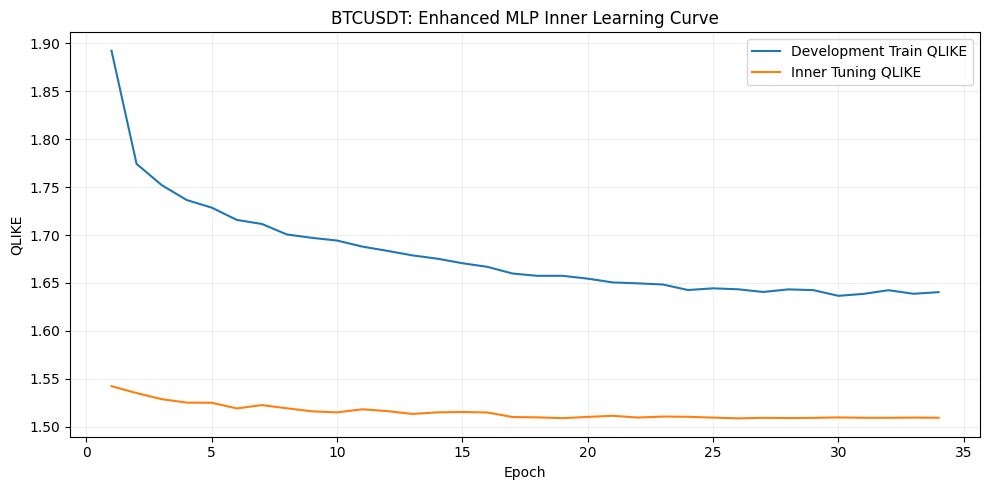

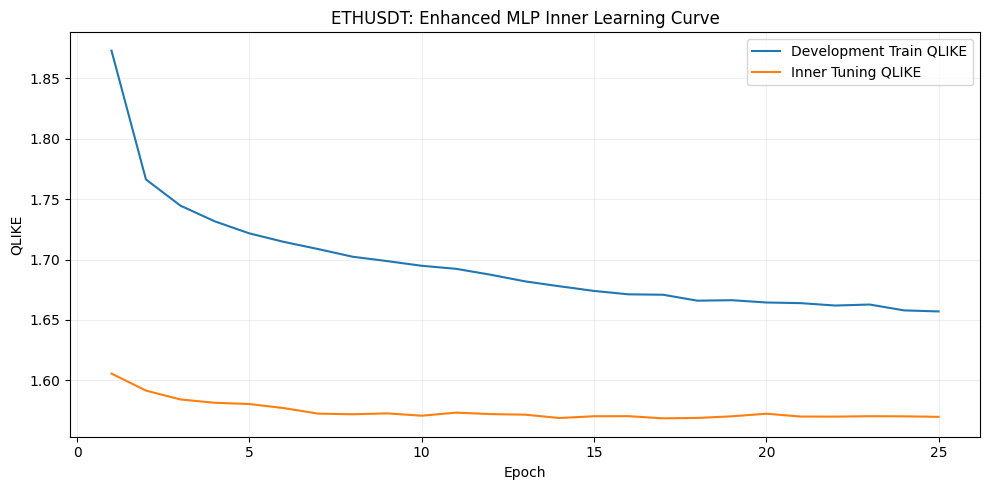

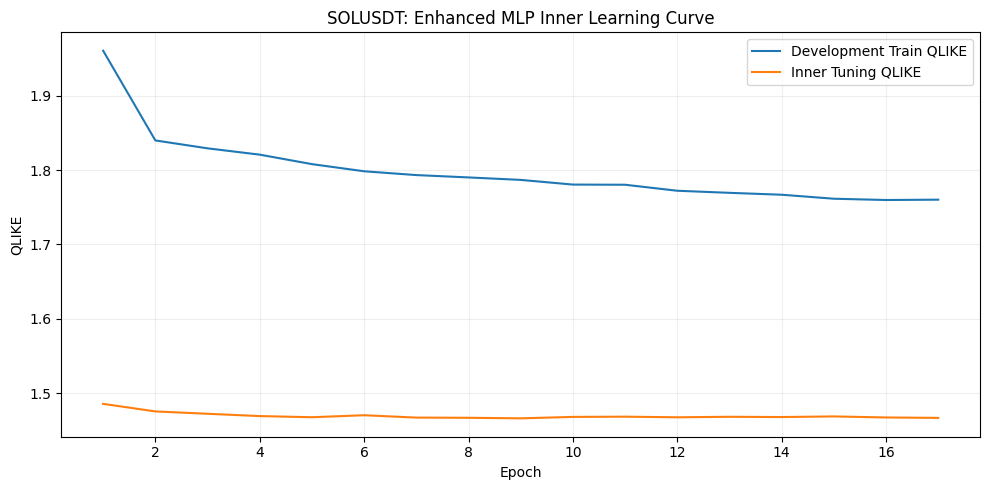

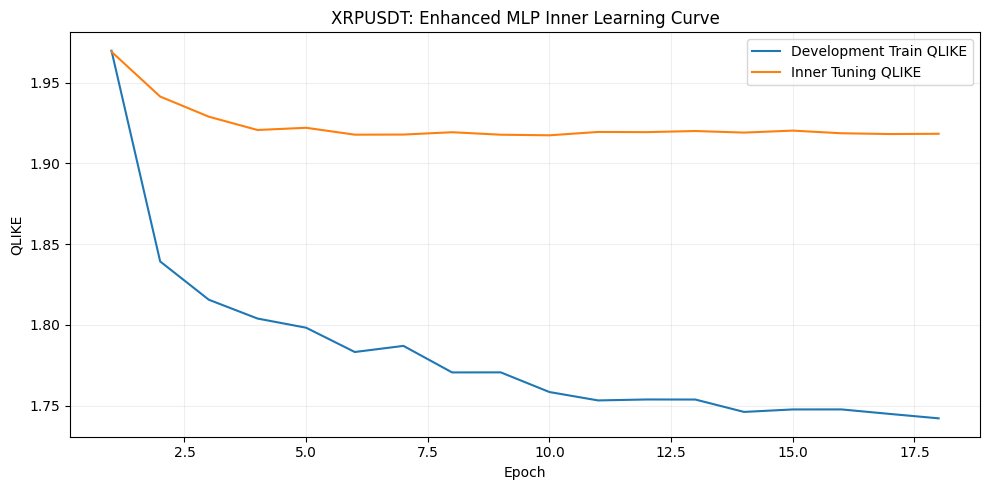

In [16]:
selected_histories_df = (
    inner_histories_df.loc[
        inner_histories_df[
            "feature_set"
        ].eq(
            SELECTED_FEATURE_SET
        )
        & np.isclose(
            inner_histories_df[
                "learning_rate_initial"
            ],
            SELECTED_LEARNING_RATE,
        )
    ]
    .copy()
)

for symbol in SYMBOLS:
    current = (
        selected_histories_df.loc[
            selected_histories_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            "epoch"
        )
    )

    plt.figure(
        figsize=(
            10,
            5,
        )
    )

    plt.plot(
        current[
            "epoch"
        ],
        current[
            "qlike_metric"
        ],
        label="Development Train QLIKE",
    )

    plt.plot(
        current[
            "epoch"
        ],
        current[
            "val_qlike_metric"
        ],
        label="Inner Tuning QLIKE",
    )

    plt.xlabel("Epoch")
    plt.ylabel("QLIKE")
    plt.title(
        f"{symbol}: Enhanced MLP Inner Learning Curve"
    )
    plt.legend()
    plt.grid(alpha=0.20)
    plt.tight_layout()

    figure_path = (
        INNER_RESULTS_ROOT
        / (
            f"{symbol}_selected_inner_"
            "qlike_curve.png"
        )
    )

    plt.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

# Part B — Final Asset-Specific MLPs

The selected feature set and learning rate are retrained on the complete original Train period.

The official Validation period is evaluated once. Test remains untouched.

## 17. Release inner feature table and build full-Train-normalized enhanced features

The final state features use the canonical Notebook 02 seasonality factors estimated from the **full original Train period only**.

In [17]:
enhanced_full_df = (
    build_enhanced_state_features(
        source_df=base_df,
        seasonality_factor_df=full_train_seasonality_df,
    )
)

full_required_columns = (
    SELECTED_FEATURE_COLUMNS
    + [
        "target_adjusted_variance",
        "target_realized_variance",
        "target_open_time",
        "target_variance_factor",
    ]
)

enhanced_full_df[
    "selected_feature_valid"
] = (
    enhanced_full_df[
        full_required_columns
    ]
    .notna()
    .all(axis=1)
    & enhanced_full_df[
        "split"
    ]
    .isin(
        [
            "train",
            "validation",
            "test",
        ]
    )
)

selected_model_rows_df = (
    enhanced_full_df.loc[
        enhanced_full_df[
            "selected_feature_valid"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

coverage_df = (
    selected_model_rows_df
    .groupby(
        [
            "symbol",
            "split",
        ]
    )
    .agg(
        rows=(
            "target_open_time",
            "size",
        ),
        first_target=(
            "target_open_time",
            "min",
        ),
        last_target=(
            "target_open_time",
            "max",
        ),
    )
    .reset_index()
)

display(
    coverage_df
)

for symbol in SYMBOLS:
    train_count = int(
        (
            selected_model_rows_df[
                "symbol"
            ].eq(symbol)
            & selected_model_rows_df[
                "split"
            ].eq("train")
        )
        .sum()
    )

    validation_count = int(
        (
            selected_model_rows_df[
                "symbol"
            ].eq(symbol)
            & selected_model_rows_df[
                "split"
            ].eq("validation")
        )
        .sum()
    )

    if (
        train_count < 10000
        or validation_count < 1000
    ):
        raise ValueError(
            f"{symbol}: insufficient final Train / "
            "Validation rows after enhanced features."
        )

print(
    "Full-Train-normalized enhanced feature table ready."
)

del base_df

gc.collect()


,symbol,split,rows,first_target,last_target
0,BTCUSDT,test,35040,2025-08-01 00:00:00+00:00,2026-07-31 23:45:00+00:00
1,BTCUSDT,train,239971,2017-08-18 04:15:00+00:00,2024-07-31 23:45:00+00:00
2,BTCUSDT,validation,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
3,ETHUSDT,test,35040,2025-08-01 00:00:00+00:00,2026-07-31 23:45:00+00:00
4,ETHUSDT,train,239971,2017-08-18 04:15:00+00:00,2024-07-31 23:45:00+00:00
5,ETHUSDT,validation,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
6,SOLUSDT,test,35040,2025-08-01 00:00:00+00:00,2026-07-31 23:45:00+00:00
7,SOLUSDT,train,138106,2020-08-12 06:15:00+00:00,2024-07-31 23:45:00+00:00
8,SOLUSDT,validation,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
9,XRPUSDT,test,35040,2025-08-01 00:00:00+00:00,2026-07-31 23:45:00+00:00


Full-Train-normalized enhanced feature table ready.


7014

## 18. Save reusable final MLP state-feature artifact

The enhanced state table is saved once and reused by the asset-specific and global MLP sections.

In [18]:
ENHANCED_FEATURES_PATH = (
    MODEL_READY_ROOT
    / (
        f"mlp_final_state_features_"
        f"{KLINE_INTERVAL}.parquet"
    )
)

ENHANCED_FEATURE_MANIFEST_PATH = (
    MANIFEST_ROOT
    / (
        f"mlp_final_state_features_"
        f"{KLINE_INTERVAL}_manifest.json"
    )
)

enhanced_save_columns = [
    "symbol",
    "open_time",
    "target_open_time",
    "split",
    "target_realized_variance",
    "target_adjusted_variance",
    "target_variance_factor",
    *FULL_ACTIVITY_FEATURES,
]

enhanced_save_df = (
    enhanced_full_df.loc[
        enhanced_full_df[
            [
                "target_realized_variance",
                "target_open_time",
                "target_variance_factor",
            ]
        ]
        .notna()
        .all(axis=1),
        enhanced_save_columns,
    ]
    .copy()
)

enhanced_save_df.to_parquet(
    ENHANCED_FEATURES_PATH,
    index=False,
)

feature_manifest = {
    "created_at_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "kline_interval":
        KLINE_INTERVAL,

    "interval_minutes":
        INTERVAL_MINUTES,

    "target":
        "next_candle_squared_log_return",

    "deseasonalization":
        "per_asset_full_train_clock_slot_variance_factor",

    "rv_state_durations":
        RV_STATE_BARS,

    "range_durations":
        RANGE_BARS,

    "semivariance_durations":
        SEMIVAR_BARS,

    "activity_durations":
        ACTIVITY_BARS,

    "lag_specs":
        [
            {
                "tag":
                    tag,

                "bars":
                    bars,
            }
            for (
                tag,
                bars,
            ) in (
                LAG_BAR_SPECS
            )
        ],

    "feature_sets":
        FEATURE_SETS,

    "selected_feature_set":
        SELECTED_FEATURE_SET,

    "selected_feature_columns":
        SELECTED_FEATURE_COLUMNS,

    "output_path":
        str(
            ENHANCED_FEATURES_PATH
        ),
}

with open(
    ENHANCED_FEATURE_MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        feature_manifest,
        file,
        indent=2,
        ensure_ascii=False,
    )

reloaded_enhanced_features = (
    pd.read_parquet(
        ENHANCED_FEATURES_PATH
    )
)

assert (
    len(
        reloaded_enhanced_features
    )
    == len(
        enhanced_save_df
    )
)

print(
    "Saved enhanced feature artifact:"
)

print(
    ENHANCED_FEATURES_PATH
)

Saved enhanced feature artifact:
/content/drive/MyDrive/Quant Research/15min/data/model_ready/15m/mlp_final_state_features_15m.parquet


## 19. Retrain one final MLP per asset on the complete original Train period

No official Validation observations are used for:

- scaler fitting;
- gradient updates;
- early stopping;
- epoch selection.

The epoch count for each asset is carried forward from the inner selected configuration.

In [19]:
final_metric_rows = []
final_prediction_frames = []
final_training_rows = []

for symbol_index, symbol in enumerate(
    SYMBOLS
):
    print(
        "\n"
        + "=" * 90
    )

    print(
        "FINAL ASSET-SPECIFIC MLP:",
        symbol,
    )

    print(
        "=" * 90
    )

    current = (
        selected_model_rows_df.loc[
            selected_model_rows_df[
                "symbol"
            ].eq(symbol)
            & selected_model_rows_df[
                "split"
            ].isin(
                [
                    "train",
                    "validation",
                ]
            )
        ]
        .sort_values(
            "target_open_time"
        )
        .copy()
    )

    train_rows = (
        current.loc[
            current[
                "split"
            ].eq("train")
        ]
    )

    validation_rows = (
        current.loc[
            current[
                "split"
            ].eq(
                "validation"
            )
        ]
    )

    scaler = StandardScaler()

    X_train = (
        scaler
        .fit_transform(
            train_rows[
                SELECTED_FEATURE_COLUMNS
            ]
            .to_numpy(
                dtype=np.float64
            )
        )
        .astype(
            np.float32
        )
    )

    X_validation = (
        scaler
        .transform(
            validation_rows[
                SELECTED_FEATURE_COLUMNS
            ]
            .to_numpy(
                dtype=np.float64
            )
        )
        .astype(
            np.float32
        )
    )

    y_train = (
        train_rows[
            "target_adjusted_variance"
        ]
        .to_numpy(
            dtype=np.float32
        )
        .reshape(
            -1,
            1,
        )
    )

    output_bias = float(
        np.log(
            np.mean(
                np.maximum(
                    y_train,
                    EPSILON,
                )
            )
        )
    )

    final_epochs = int(
        SELECTED_EPOCH_BY_ASSET[
            symbol
        ]
    )

    if final_epochs < 1:
        raise ValueError(
            f"{symbol}: invalid final epoch count."
        )

    model_seed = (
        BASE_SEED
        + 900000
        + symbol_index
        * 100
    )

    tf.keras.backend.clear_session()

    random.seed(
        model_seed
    )

    np.random.seed(
        model_seed
    )

    tf.keras.utils.set_random_seed(
        model_seed
    )

    model = build_enhanced_mlp(
        n_features=len(
            SELECTED_FEATURE_COLUMNS
        ),
        learning_rate=SELECTED_LEARNING_RATE,
        output_bias=output_bias,
    )

    started = time.time()

    final_history = model.fit(
        X_train,
        y_train,
        epochs=final_epochs,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=2,
    )

    training_seconds = (
        time.time()
        - started
    )

    predicted_log_adjusted_variance = (
        model.predict(
            X_validation,
            batch_size=BATCH_SIZE,
            verbose=0,
        )
        .reshape(-1)
    )

    predicted_adjusted_variance = np.exp(
        predicted_log_adjusted_variance
    )

    predicted_variance = (
        predicted_adjusted_variance
        * validation_rows[
            "target_variance_factor"
        ]
        .to_numpy(
            dtype=float
        )
    )

    actual_variance = (
        validation_rows[
            "target_realized_variance"
        ]
        .to_numpy(
            dtype=float
        )
    )

    if (
        not np.isfinite(
            predicted_variance
        ).all()
        or not (
            predicted_variance
            > 0
        ).all()
    ):
        raise ValueError(
            f"{symbol}: invalid final Validation predictions."
        )

    metrics = calculate_metrics(
        actual_variance=actual_variance,
        predicted_variance=predicted_variance,
    )

    symbol_model_dir = (
        MODEL_ROOT
        / symbol
    )

    symbol_artifact_dir = (
        ARTIFACT_ROOT
        / symbol
    )

    symbol_result_dir = (
        RESULTS_ROOT
        / symbol
    )

    for directory in [
        symbol_model_dir,
        symbol_artifact_dir,
        symbol_result_dir,
    ]:
        directory.mkdir(
            parents=True,
            exist_ok=True,
        )

    model_path = (
        symbol_model_dir
        / "final_asset_specific_mlp.keras"
    )

    scaler_path = (
        symbol_artifact_dir
        / "feature_scaler.joblib"
    )

    model.save(
        model_path
    )

    joblib.dump(
        scaler,
        scaler_path,
    )

    # Reload saved model before recording the final prediction artifact.
    reloaded_model = tf.keras.models.load_model(
        model_path,
        compile=False,
    )

    reloaded_log_adjusted = (
        reloaded_model.predict(
            X_validation,
            batch_size=BATCH_SIZE,
            verbose=0,
        )
        .reshape(-1)
    )

    reload_difference = float(
        np.max(
            np.abs(
                reloaded_log_adjusted
                - predicted_log_adjusted_variance
            )
        )
    )

    if reload_difference > 1e-6:
        raise ValueError(
            f"{symbol}: saved-model reload prediction "
            f"difference={reload_difference}"
        )

    prediction_df = pd.DataFrame({
        "symbol":
            symbol,

        "target_open_time":
            validation_rows[
                "target_open_time"
            ]
            .to_numpy(),

        "actual_variance":
            actual_variance,

        "target_variance_factor":
            validation_rows[
                "target_variance_factor"
            ]
            .to_numpy(
                dtype=float
            ),

        "predicted_adjusted_variance":
            predicted_adjusted_variance,

        "predicted_variance":
            predicted_variance,

        "predicted_log_adjusted_variance":
            predicted_log_adjusted_variance,
    })

    prediction_df.to_parquet(
        symbol_result_dir
        / "validation_predictions.parquet",
        index=False,
    )

    final_history_df = pd.DataFrame(
        final_history.history
    )

    final_history_df[
        "epoch"
    ] = np.arange(
        1,
        len(
            final_history_df
        )
        + 1,
    )

    final_history_df.to_csv(
        symbol_result_dir
        / "final_train_history.csv",
        index=False,
    )

    final_metric_rows.append({
        "symbol":
            symbol,

        "model":
            "Asset-Specific MLP",

        "feature_set":
            SELECTED_FEATURE_SET,

        "feature_count":
            len(
                SELECTED_FEATURE_COLUMNS
            ),

        "learning_rate":
            SELECTED_LEARNING_RATE,

        "epochs":
            final_epochs,

        "train_rows":
            int(
                len(
                    train_rows
                )
            ),

        "validation_rows":
            int(
                len(
                    validation_rows
                )
            ),

        "mae":
            metrics[
                "mae"
            ],

        "rmse":
            metrics[
                "rmse"
            ],

        "qlike":
            metrics[
                "qlike"
            ],

        "training_seconds":
            float(
                training_seconds
            ),

        "model_path":
            str(
                model_path
            ),

        "scaler_path":
            str(
                scaler_path
            ),
    })

    final_prediction_frames.append(
        prediction_df
    )

    final_training_rows.append({
        "symbol":
            symbol,

        "inner_selected_epoch":
            final_epochs,

        "full_train_rows":
            int(
                len(
                    train_rows
                )
            ),

        "parameter_count":
            int(
                reloaded_model.count_params()
            ),

        "training_seconds":
            float(
                training_seconds
            ),

        "reload_max_log_prediction_difference":
            reload_difference,
    })

    print(
        "Validation | "
        f"MAE={metrics['mae']:.10f} | "
        f"RMSE={metrics['rmse']:.10f} | "
        f"QLIKE={metrics['qlike']:.6f}"
    )

    del model
    del reloaded_model
    del scaler
    del X_train
    del X_validation
    del y_train

    gc.collect()


asset_specific_validation_metrics_df = (
    pd.DataFrame(
        final_metric_rows
    )
)

asset_specific_validation_predictions_df = (
    pd.concat(
        final_prediction_frames,
        ignore_index=True,
    )
)

final_training_summary_df = (
    pd.DataFrame(
        final_training_rows
    )
)

display(
    asset_specific_validation_metrics_df.style.format({
        "learning_rate":
            "{:.1e}",
        "mae":
            "{:.10f}",
        "rmse":
            "{:.10f}",
        "qlike":
            "{:.6f}",
        "training_seconds":
            "{:.1f}",
    })
)


FINAL ASSET-SPECIFIC MLP: BTCUSDT
Epoch 1/26
118/118 - 12s - 101ms/step - loss: -1.0507e+01 - qlike_metric: 1.9011
Epoch 2/26
118/118 - 5s - 43ms/step - loss: -1.0654e+01 - qlike_metric: 1.7542
Epoch 3/26
118/118 - 6s - 53ms/step - loss: -1.0674e+01 - qlike_metric: 1.7340
Epoch 4/26
118/118 - 5s - 46ms/step - loss: -1.0687e+01 - qlike_metric: 1.7212
Epoch 5/26
118/118 - 5s - 41ms/step - loss: -1.0698e+01 - qlike_metric: 1.7104
Epoch 6/26
118/118 - 7s - 59ms/step - loss: -1.0701e+01 - qlike_metric: 1.7072
Epoch 7/26
118/118 - 5s - 42ms/step - loss: -1.0710e+01 - qlike_metric: 1.6981
Epoch 8/26
118/118 - 6s - 48ms/step - loss: -1.0715e+01 - qlike_metric: 1.6929
Epoch 9/26
118/118 - 7s - 57ms/step - loss: -1.0723e+01 - qlike_metric: 1.6856
Epoch 10/26
118/118 - 5s - 42ms/step - loss: -1.0729e+01 - qlike_metric: 1.6799
Epoch 11/26
118/118 - 7s - 55ms/step - loss: -1.0729e+01 - qlike_metric: 1.6792
Epoch 12/26
118/118 - 5s - 46ms/step - loss: -1.0733e+01 - qlike_metric: 1.6753
Epoch 13/26


,symbol,model,feature_set,feature_count,learning_rate,epochs,train_rows,validation_rows,mae,rmse,qlike,training_seconds,model_path,scaler_path
0,BTCUSDT,Asset-Specific MLP,FULL_ACTIVITY,48,3.0e-04,26,239971,35040,0.0000074116,0.0000297903,1.451999,161.4,/content/drive/MyDrive/Quant Research/15min/models/15m/MLP_FINAL/BTCUSDT/final_asset_specific_mlp.keras,/content/drive/MyDrive/Quant Research/15min/artifacts/15m/MLP_FINAL/BTCUSDT/feature_scaler.joblib
1,ETHUSDT,Asset-Specific MLP,FULL_ACTIVITY,48,3.0e-04,17,239971,35040,0.0000168370,0.0000939594,1.511114,111.6,/content/drive/MyDrive/Quant Research/15min/models/15m/MLP_FINAL/ETHUSDT/final_asset_specific_mlp.keras,/content/drive/MyDrive/Quant Research/15min/artifacts/15m/MLP_FINAL/ETHUSDT/feature_scaler.joblib
2,SOLUSDT,Asset-Specific MLP,FULL_ACTIVITY,48,3.0e-04,9,138106,35040,0.0000248332,0.0000845668,1.418898,35.8,/content/drive/MyDrive/Quant Research/15min/models/15m/MLP_FINAL/SOLUSDT/final_asset_specific_mlp.keras,/content/drive/MyDrive/Quant Research/15min/artifacts/15m/MLP_FINAL/SOLUSDT/feature_scaler.joblib
3,XRPUSDT,Asset-Specific MLP,FULL_ACTIVITY,48,3.0e-04,10,215927,35040,0.0000338817,0.0001623113,1.558998,67.9,/content/drive/MyDrive/Quant Research/15min/models/15m/MLP_FINAL/XRPUSDT/final_asset_specific_mlp.keras,/content/drive/MyDrive/Quant Research/15min/artifacts/15m/MLP_FINAL/XRPUSDT/feature_scaler.joblib


# Part C — Global Enhanced MLP

The global model pools all four assets while preserving:

- one Train-only scaler per asset;
- explicit one-hot asset identity;
- equal total optimization weight per asset so longer histories do not dominate;
- the same selected feature set and learning rate as the asset-specific model;
- inner-tuning-only epoch selection;
- one-time official Validation evaluation.

## 20. Global-model helpers

In [20]:
ASSET_ORDER = list(SYMBOLS)

ASSET_TO_INDEX = {
    symbol: index
    for index, symbol in enumerate(ASSET_ORDER)
}

N_ASSETS = len(ASSET_ORDER)


def one_hot_for_asset(
    symbol,
    n_rows,
):
    output = np.zeros(
        (n_rows, N_ASSETS),
        dtype=np.float32,
    )

    output[
        :,
        ASSET_TO_INDEX[symbol],
    ] = 1.0

    return output


def balanced_asset_weights(
    asset_index_array,
):
    asset_index_array = np.asarray(
        asset_index_array,
        dtype=np.int64,
    )

    n_total = len(asset_index_array)

    weights = np.empty(
        n_total,
        dtype=np.float32,
    )

    unique_assets = np.unique(
        asset_index_array
    )

    for asset_index in unique_assets:
        mask = (
            asset_index_array
            == asset_index
        )

        count = int(mask.sum())

        weights[mask] = (
            n_total
            / (
                len(unique_assets)
                * count
            )
        )

    return weights


def build_global_enhanced_mlp(
    n_features,
    n_assets,
    learning_rate,
    output_bias,
):
    state_input = Input(
        shape=(n_features,),
        name="state_features",
    )

    asset_input = Input(
        shape=(n_assets,),
        name="asset_identity",
    )

    asset_embedding = Dense(
        8,
        activation="swish",
        name="asset_embedding",
    )(
        asset_input
    )

    x = Concatenate(
        name="state_asset_concat"
    )(
        [
            state_input,
            asset_embedding,
        ]
    )

    x = Dense(
        128,
        activation="swish",
        name="dense_input",
    )(x)

    x = LayerNormalization(
        name="norm_input"
    )(x)

    x = Dropout(
        DROPOUT_1,
        name="dropout_input",
    )(x)

    residual = x

    x = Dense(
        128,
        activation="swish",
        name="residual_dense_1",
    )(x)

    x = Dropout(
        DROPOUT_RESIDUAL,
        name="residual_dropout",
    )(x)

    x = Dense(
        128,
        activation=None,
        name="residual_dense_2",
    )(x)

    x = Add(
        name="residual_add"
    )(
        [
            residual,
            x,
        ]
    )

    x = LayerNormalization(
        name="norm_residual"
    )(x)

    x = Activation(
        "swish",
        name="residual_activation",
    )(x)

    x = Dense(
        64,
        activation="swish",
        name="dense_64",
    )(x)

    x = Dropout(
        DROPOUT_2,
        name="dropout_64",
    )(x)

    x = Dense(
        32,
        activation="swish",
        name="dense_32",
    )(x)

    output = Dense(
        1,
        activation=None,
        bias_initializer=Constant(
            output_bias
        ),
        name="log_adjusted_variance",
    )(x)

    model = Model(
        inputs=[
            state_input,
            asset_input,
        ],
        outputs=output,
        name="global_enhanced_intraday_mlp",
    )

    model.compile(
        optimizer=make_optimizer(
            learning_rate
        ),
        loss=gaussian_variance_qlike_loss,
        metrics=[
            qlike_metric,
        ],
    )

    return model

## 21. Select the global epoch count inside Train

The local inner grid has already frozen the feature set and learning rate.

The global inner run therefore selects only the pooled model's epoch count.

Epoch 1/80
374/374 - 23s - 62ms/step - loss: -9.9226e+00 - qlike_metric: 1.8693 - val_loss: -1.0581e+01 - val_qlike_metric: 1.6260 - learning_rate: 3.0000e-04
Epoch 2/80
374/374 - 20s - 55ms/step - loss: -1.0006e+01 - qlike_metric: 1.7875 - val_loss: -1.0593e+01 - val_qlike_metric: 1.6137 - learning_rate: 3.0000e-04
Epoch 3/80
374/374 - 19s - 52ms/step - loss: -1.0027e+01 - qlike_metric: 1.7686 - val_loss: -1.0599e+01 - val_qlike_metric: 1.6084 - learning_rate: 3.0000e-04
Epoch 4/80
374/374 - 19s - 51ms/step - loss: -1.0033e+01 - qlike_metric: 1.7598 - val_loss: -1.0601e+01 - val_qlike_metric: 1.6061 - learning_rate: 3.0000e-04
Epoch 5/80
374/374 - 20s - 53ms/step - loss: -1.0042e+01 - qlike_metric: 1.7525 - val_loss: -1.0603e+01 - val_qlike_metric: 1.6045 - learning_rate: 3.0000e-04
Epoch 6/80
374/374 - 19s - 52ms/step - loss: -1.0051e+01 - qlike_metric: 1.7442 - val_loss: -1.0601e+01 - val_qlike_metric: 1.6057 - learning_rate: 3.0000e-04
Epoch 7/80
374/374 - 20s - 52ms/step - loss: -

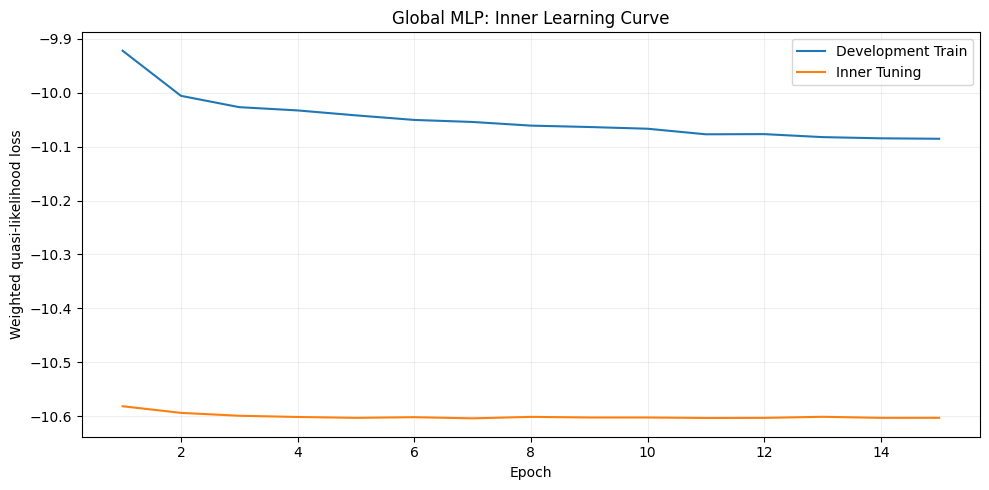

4758

In [22]:
global_dev_X_parts = []
global_dev_asset_parts = []
global_dev_y_parts = []
global_dev_asset_index_parts = []

global_tune_X_parts = []
global_tune_asset_parts = []
global_tune_y_parts = []
global_tune_asset_index_parts = []

for symbol in SYMBOLS:

    current = (
        enhanced_inner_df.loc[
            enhanced_inner_df[
                "symbol"
            ].eq(symbol)
            & enhanced_inner_df[
                "inner_partition"
            ].isin(
                [
                    "development_train",
                    "inner_tuning",
                ]
            )
        ]
        .sort_values(
            "target_open_time"
        )
        .copy()
    )

    development = (
        current.loc[
            current[
                "inner_partition"
            ].eq(
                "development_train"
            )
        ]
    )

    tuning = (
        current.loc[
            current[
                "inner_partition"
            ].eq(
                "inner_tuning"
            )
        ]
    )

    scaler = StandardScaler()

    X_dev = (
        scaler.fit_transform(
            development[
                SELECTED_FEATURE_COLUMNS
            ].to_numpy(
                dtype=np.float64
            )
        )
        .astype(np.float32)
    )

    X_tune = (
        scaler.transform(
            tuning[
                SELECTED_FEATURE_COLUMNS
            ].to_numpy(
                dtype=np.float64
            )
        )
        .astype(np.float32)
    )

    y_dev = (
        development[
            "target_adjusted_variance"
        ]
        .to_numpy(
            dtype=np.float32
        )
        .reshape(
            -1,
            1,
        )
    )

    y_tune = (
        tuning[
            "target_adjusted_variance"
        ]
        .to_numpy(
            dtype=np.float32
        )
        .reshape(
            -1,
            1,
        )
    )

    asset_index = (
        ASSET_TO_INDEX[symbol]
    )

    global_dev_X_parts.append(X_dev)
    global_dev_asset_parts.append(
        one_hot_for_asset(
            symbol,
            len(development),
        )
    )
    global_dev_y_parts.append(y_dev)
    global_dev_asset_index_parts.append(
        np.full(
            len(development),
            asset_index,
            dtype=np.int64,
        )
    )

    global_tune_X_parts.append(X_tune)
    global_tune_asset_parts.append(
        one_hot_for_asset(
            symbol,
            len(tuning),
        )
    )
    global_tune_y_parts.append(y_tune)
    global_tune_asset_index_parts.append(
        np.full(
            len(tuning),
            asset_index,
            dtype=np.int64,
        )
    )


GLOBAL_DEV_X = np.concatenate(
    global_dev_X_parts,
    axis=0,
)

GLOBAL_DEV_ASSET = np.concatenate(
    global_dev_asset_parts,
    axis=0,
)

GLOBAL_DEV_Y = np.concatenate(
    global_dev_y_parts,
    axis=0,
)

GLOBAL_DEV_ASSET_INDEX = np.concatenate(
    global_dev_asset_index_parts,
    axis=0,
)

GLOBAL_TUNE_X = np.concatenate(
    global_tune_X_parts,
    axis=0,
)

GLOBAL_TUNE_ASSET = np.concatenate(
    global_tune_asset_parts,
    axis=0,
)

GLOBAL_TUNE_Y = np.concatenate(
    global_tune_y_parts,
    axis=0,
)

GLOBAL_TUNE_ASSET_INDEX = np.concatenate(
    global_tune_asset_index_parts,
    axis=0,
)

GLOBAL_DEV_WEIGHTS = balanced_asset_weights(
    GLOBAL_DEV_ASSET_INDEX
)

GLOBAL_TUNE_WEIGHTS = balanced_asset_weights(
    GLOBAL_TUNE_ASSET_INDEX
)

global_output_bias = float(
    np.log(
        np.average(
            np.maximum(
                GLOBAL_DEV_Y.reshape(-1),
                EPSILON,
            ),
            weights=GLOBAL_DEV_WEIGHTS.reshape(-1),
        )
    )
)

tf.keras.backend.clear_session()

global_inner_seed = (
    BASE_SEED
    + 700000
)

random.seed(global_inner_seed)
np.random.seed(global_inner_seed)
tf.keras.utils.set_random_seed(
    global_inner_seed
)

global_inner_model = (
    build_global_enhanced_mlp(
        n_features=len(
            SELECTED_FEATURE_COLUMNS
        ),
        n_assets=N_ASSETS,
        learning_rate=SELECTED_LEARNING_RATE,
        output_bias=global_output_bias,
    )
)

global_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        min_delta=1e-4,
        restore_best_weights=True,
        mode="min",
        verbose=1,
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=LR_PATIENCE,
        min_lr=MIN_LEARNING_RATE,
        mode="min",
        verbose=1,
    ),
]

global_inner_history = (
    global_inner_model.fit(
        [
            GLOBAL_DEV_X,
            GLOBAL_DEV_ASSET,
        ],
        GLOBAL_DEV_Y,
        sample_weight=GLOBAL_DEV_WEIGHTS,
        validation_data=(
            [
                GLOBAL_TUNE_X,
                GLOBAL_TUNE_ASSET,
            ],
            GLOBAL_TUNE_Y,
            GLOBAL_TUNE_WEIGHTS,
        ),
        epochs=MAX_INNER_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=global_callbacks,
        verbose=2,
    )
)

global_inner_history_df = pd.DataFrame(
    global_inner_history.history
)

global_inner_history_df[
    "epoch"
] = np.arange(
    1,
    len(global_inner_history_df)
    + 1,
)

GLOBAL_FINAL_EPOCHS = int(
    global_inner_history_df[
        "val_loss"
    ]
    .idxmin()
    + 1
)

print(
    "Selected global epoch count:",
    GLOBAL_FINAL_EPOCHS,
)

plt.figure(
    figsize=(
        10,
        5,
    )
)

plt.plot(
    global_inner_history_df[
        "epoch"
    ],
    global_inner_history_df[
        "loss"
    ],
    label="Development Train",
)

plt.plot(
    global_inner_history_df[
        "epoch"
    ],
    global_inner_history_df[
        "val_loss"
    ],
    label="Inner Tuning",
)

plt.xlabel("Epoch")
plt.ylabel(
    "Weighted quasi-likelihood loss"
)
plt.title(
    "Global MLP: Inner Learning Curve"
)
plt.legend()
plt.grid(alpha=0.20)
plt.tight_layout()

plt.savefig(
    INNER_RESULTS_ROOT
    / "global_inner_learning_curve.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

del global_inner_model
del GLOBAL_DEV_X
del GLOBAL_DEV_ASSET
del GLOBAL_DEV_Y
del GLOBAL_DEV_ASSET_INDEX
del GLOBAL_DEV_WEIGHTS
del GLOBAL_TUNE_X
del GLOBAL_TUNE_ASSET
del GLOBAL_TUNE_Y
del GLOBAL_TUNE_ASSET_INDEX
del GLOBAL_TUNE_WEIGHTS

gc.collect()

## 22. Train the final global model on full Train and evaluate official Validation

In [23]:
global_final_scalers = {}

global_train_X_parts = []
global_train_asset_parts = []
global_train_y_parts = []
global_train_asset_index_parts = []

global_validation_X_parts = []
global_validation_asset_parts = []
global_validation_factor_parts = []
global_validation_actual_parts = []
global_validation_time_parts = []
global_validation_symbol_parts = []

for symbol in SYMBOLS:

    current = (
        selected_model_rows_df.loc[
            selected_model_rows_df[
                "symbol"
            ].eq(symbol)
            & selected_model_rows_df[
                "split"
            ].isin(
                [
                    "train",
                    "validation",
                ]
            )
        ]
        .sort_values(
            "target_open_time"
        )
        .copy()
    )

    train_rows = (
        current.loc[
            current[
                "split"
            ].eq("train")
        ]
    )

    validation_rows = (
        current.loc[
            current[
                "split"
            ].eq(
                "validation"
            )
        ]
    )

    scaler = StandardScaler()

    X_train = (
        scaler.fit_transform(
            train_rows[
                SELECTED_FEATURE_COLUMNS
            ].to_numpy(
                dtype=np.float64
            )
        )
        .astype(np.float32)
    )

    X_validation = (
        scaler.transform(
            validation_rows[
                SELECTED_FEATURE_COLUMNS
            ].to_numpy(
                dtype=np.float64
            )
        )
        .astype(np.float32)
    )

    y_train = (
        train_rows[
            "target_adjusted_variance"
        ]
        .to_numpy(
            dtype=np.float32
        )
        .reshape(
            -1,
            1,
        )
    )

    asset_index = (
        ASSET_TO_INDEX[symbol]
    )

    global_final_scalers[
        symbol
    ] = scaler

    global_train_X_parts.append(X_train)
    global_train_asset_parts.append(
        one_hot_for_asset(
            symbol,
            len(train_rows),
        )
    )
    global_train_y_parts.append(y_train)
    global_train_asset_index_parts.append(
        np.full(
            len(train_rows),
            asset_index,
            dtype=np.int64,
        )
    )

    global_validation_X_parts.append(
        X_validation
    )
    global_validation_asset_parts.append(
        one_hot_for_asset(
            symbol,
            len(validation_rows),
        )
    )
    global_validation_factor_parts.append(
        validation_rows[
            "target_variance_factor"
        ]
        .to_numpy(dtype=float)
    )
    global_validation_actual_parts.append(
        validation_rows[
            "target_realized_variance"
        ]
        .to_numpy(dtype=float)
    )
    global_validation_time_parts.append(
        validation_rows[
            "target_open_time"
        ]
        .to_numpy()
    )
    global_validation_symbol_parts.append(
        np.full(
            len(validation_rows),
            symbol,
            dtype=object,
        )
    )


GLOBAL_TRAIN_X = np.concatenate(
    global_train_X_parts,
    axis=0,
)

GLOBAL_TRAIN_ASSET = np.concatenate(
    global_train_asset_parts,
    axis=0,
)

GLOBAL_TRAIN_Y = np.concatenate(
    global_train_y_parts,
    axis=0,
)

GLOBAL_TRAIN_ASSET_INDEX = np.concatenate(
    global_train_asset_index_parts,
    axis=0,
)

GLOBAL_TRAIN_WEIGHTS = balanced_asset_weights(
    GLOBAL_TRAIN_ASSET_INDEX
)

GLOBAL_VALIDATION_X = np.concatenate(
    global_validation_X_parts,
    axis=0,
)

GLOBAL_VALIDATION_ASSET = np.concatenate(
    global_validation_asset_parts,
    axis=0,
)

GLOBAL_VALIDATION_FACTOR = np.concatenate(
    global_validation_factor_parts,
    axis=0,
)

GLOBAL_VALIDATION_ACTUAL = np.concatenate(
    global_validation_actual_parts,
    axis=0,
)

GLOBAL_VALIDATION_TIME = np.concatenate(
    global_validation_time_parts,
    axis=0,
)

GLOBAL_VALIDATION_SYMBOL = np.concatenate(
    global_validation_symbol_parts,
    axis=0,
)

global_full_output_bias = float(
    np.log(
        np.average(
            np.maximum(
                GLOBAL_TRAIN_Y.reshape(-1),
                EPSILON,
            ),
            weights=GLOBAL_TRAIN_WEIGHTS.reshape(-1),
        )
    )
)

global_final_seed = (
    BASE_SEED
    + 800000
)

tf.keras.backend.clear_session()
random.seed(global_final_seed)
np.random.seed(global_final_seed)
tf.keras.utils.set_random_seed(
    global_final_seed
)

global_model = (
    build_global_enhanced_mlp(
        n_features=len(
            SELECTED_FEATURE_COLUMNS
        ),
        n_assets=N_ASSETS,
        learning_rate=SELECTED_LEARNING_RATE,
        output_bias=global_full_output_bias,
    )
)

global_started = time.time()

global_final_history = (
    global_model.fit(
        [
            GLOBAL_TRAIN_X,
            GLOBAL_TRAIN_ASSET,
        ],
        GLOBAL_TRAIN_Y,
        sample_weight=GLOBAL_TRAIN_WEIGHTS,
        epochs=GLOBAL_FINAL_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=2,
    )
)

global_training_seconds = (
    time.time()
    - global_started
)

global_final_history_df = pd.DataFrame(
    global_final_history.history
)

global_final_history_df[
    "epoch"
] = np.arange(
    1,
    len(global_final_history_df)
    + 1,
)

predicted_global_log_adjusted = (
    global_model.predict(
        [
            GLOBAL_VALIDATION_X,
            GLOBAL_VALIDATION_ASSET,
        ],
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    .reshape(-1)
)

predicted_global_adjusted = np.exp(
    predicted_global_log_adjusted
)

predicted_global_variance = (
    predicted_global_adjusted
    * GLOBAL_VALIDATION_FACTOR
)

if (
    not np.isfinite(
        predicted_global_variance
    ).all()
    or not (
        predicted_global_variance
        > 0
    ).all()
):
    raise ValueError(
        "Global MLP produced invalid Validation predictions."
    )

GLOBAL_MODEL_PATH = (
    MODEL_ROOT
    / "GLOBAL_4_ASSETS"
    / "final_global_mlp.keras"
)

GLOBAL_SCALERS_PATH = (
    ARTIFACT_ROOT
    / "GLOBAL_4_ASSETS"
    / "feature_scalers_by_asset.joblib"
)

GLOBAL_MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

GLOBAL_SCALERS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

global_model.save(
    GLOBAL_MODEL_PATH
)

joblib.dump(
    global_final_scalers,
    GLOBAL_SCALERS_PATH,
)

reloaded_global_model = (
    tf.keras.models.load_model(
        GLOBAL_MODEL_PATH,
        compile=False,
    )
)

reload_global_log = (
    reloaded_global_model.predict(
        [
            GLOBAL_VALIDATION_X,
            GLOBAL_VALIDATION_ASSET,
        ],
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    .reshape(-1)
)

global_reload_difference = float(
    np.max(
        np.abs(
            reload_global_log
            - predicted_global_log_adjusted
        )
    )
)

if global_reload_difference > 1e-6:
    raise ValueError(
        "Global saved-model reload difference: "
        f"{global_reload_difference}"
    )

global_validation_predictions_df = pd.DataFrame({
    "symbol":
        GLOBAL_VALIDATION_SYMBOL,
    "target_open_time":
        GLOBAL_VALIDATION_TIME,
    "actual_variance":
        GLOBAL_VALIDATION_ACTUAL,
    "target_variance_factor":
        GLOBAL_VALIDATION_FACTOR,
    "predicted_adjusted_variance":
        predicted_global_adjusted,
    "predicted_variance":
        predicted_global_variance,
    "predicted_log_adjusted_variance":
        predicted_global_log_adjusted,
})

global_validation_predictions_df[
    "target_open_time"
] = pd.to_datetime(
    global_validation_predictions_df[
        "target_open_time"
    ],
    utc=True,
    errors="raise",
)

global_metric_rows = []

for symbol in SYMBOLS:

    current = (
        global_validation_predictions_df.loc[
            global_validation_predictions_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            "target_open_time"
        )
    )

    metrics = calculate_metrics(
        actual_variance=current[
            "actual_variance"
        ].to_numpy(
            dtype=float
        ),
        predicted_variance=current[
            "predicted_variance"
        ].to_numpy(
            dtype=float
        ),
    )

    global_metric_rows.append({
        "symbol":
            symbol,
        "model":
            "Global MLP",
        "feature_set":
            SELECTED_FEATURE_SET,
        "feature_count":
            len(
                SELECTED_FEATURE_COLUMNS
            ),
        "learning_rate":
            SELECTED_LEARNING_RATE,
        "epochs":
            GLOBAL_FINAL_EPOCHS,
        "validation_rows":
            int(
                len(current)
            ),
        "mae":
            metrics["mae"],
        "rmse":
            metrics["rmse"],
        "qlike":
            metrics["qlike"],
    })


global_validation_metrics_df = (
    pd.DataFrame(
        global_metric_rows
    )
)

display(
    global_validation_metrics_df.style.format({
        "learning_rate":
            "{:.1e}",
        "mae":
            "{:.10f}",
        "rmse":
            "{:.10f}",
        "qlike":
            "{:.6f}",
    })
)

print(
    "Global training seconds:",
    f"{global_training_seconds:.1f}",
)

print(
    "Global saved-model reload max difference:",
    global_reload_difference,
)

del global_model
del reloaded_global_model
del GLOBAL_TRAIN_X
del GLOBAL_TRAIN_ASSET
del GLOBAL_TRAIN_Y
del GLOBAL_TRAIN_ASSET_INDEX
del GLOBAL_TRAIN_WEIGHTS
del GLOBAL_VALIDATION_X
del GLOBAL_VALIDATION_ASSET

gc.collect()

Epoch 1/7
408/408 - 24s - 58ms/step - loss: -1.0001e+01 - qlike_metric: 1.8310
Epoch 2/7
408/408 - 22s - 54ms/step - loss: -1.0065e+01 - qlike_metric: 1.7684
Epoch 3/7
408/408 - 20s - 48ms/step - loss: -1.0077e+01 - qlike_metric: 1.7566
Epoch 4/7
408/408 - 19s - 48ms/step - loss: -1.0091e+01 - qlike_metric: 1.7419
Epoch 5/7
408/408 - 22s - 53ms/step - loss: -1.0095e+01 - qlike_metric: 1.7381
Epoch 6/7
408/408 - 20s - 48ms/step - loss: -1.0103e+01 - qlike_metric: 1.7302
Epoch 7/7
408/408 - 21s - 52ms/step - loss: -1.0108e+01 - qlike_metric: 1.7248


,symbol,model,feature_set,feature_count,learning_rate,epochs,validation_rows,mae,rmse,qlike
0,BTCUSDT,Global MLP,FULL_ACTIVITY,48,3.0e-04,7,35040,0.0000077988,0.0000306647,1.449854
1,ETHUSDT,Global MLP,FULL_ACTIVITY,48,3.0e-04,7,35040,0.0000167457,0.0000956796,1.513227
2,SOLUSDT,Global MLP,FULL_ACTIVITY,48,3.0e-04,7,35040,0.0000242778,0.0000864806,1.448428
3,XRPUSDT,Global MLP,FULL_ACTIVITY,48,3.0e-04,7,35040,0.0000340004,0.0001636964,1.563912


Global training seconds: 147.9
Global saved-model reload max difference: 0.0


2552

# Part D — Fair Validation comparison with ARCH

The final table compares only:

- Asset-Specific MLP;
- Global MLP;
- GARCH(1,1);
- GJR-GARCH(1,1);
- EGARCH(1,1).

All metrics are recomputed on identical Validation timestamps within each asset.

## 23. Load ARCH Validation predictions

In [24]:
ARCH_PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "results"
    / KLINE_INTERVAL
    / "ARCH"
    / "arch_validation_predictions.parquet"
)

if not ARCH_PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        "Notebook 03 ARCH Validation predictions were not found:\n"
        f"{ARCH_PREDICTIONS_PATH}"
    )

arch_predictions_df = pd.read_parquet(
    ARCH_PREDICTIONS_PATH
)

arch_predictions_df[
    "target_open_time"
] = pd.to_datetime(
    arch_predictions_df[
        "target_open_time"
    ],
    utc=True,
    errors="raise",
)

asset_specific_validation_predictions_df[
    "target_open_time"
] = pd.to_datetime(
    asset_specific_validation_predictions_df[
        "target_open_time"
    ],
    utc=True,
    errors="raise",
)

print(
    "ARCH models:",
    sorted(
        arch_predictions_df[
            "model"
        ]
        .unique()
        .tolist()
    ),
)

ARCH models: ['EGARCH(1,1)', 'GARCH(1,1)', 'GJR-GARCH(1,1)']


## 24. Recompute all Validation metrics on common dates

In [25]:
comparison_metric_rows = []
comparison_date_rows = []

for symbol in SYMBOLS:

    local_symbol = (
        asset_specific_validation_predictions_df.loc[
            asset_specific_validation_predictions_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    global_symbol = (
        global_validation_predictions_df.loc[
            global_validation_predictions_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    arch_symbol = (
        arch_predictions_df.loc[
            arch_predictions_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    arch_models = sorted(
        arch_symbol[
            "model"
        ]
        .unique()
        .tolist()
    )

    date_sets = [
        set(
            local_symbol[
                "target_open_time"
            ]
        ),
        set(
            global_symbol[
                "target_open_time"
            ]
        ),
    ]

    for model_name in arch_models:
        date_sets.append(
            set(
                arch_symbol.loc[
                    arch_symbol[
                        "model"
                    ].eq(model_name),
                    "target_open_time",
                ]
            )
        )

    common_dates = set.intersection(
        *date_sets
    )

    if len(common_dates) < 1000:
        raise ValueError(
            f"{symbol}: insufficient common Validation dates."
        )

    comparison_date_rows.append({
        "symbol":
            symbol,
        "common_validation_dates":
            len(common_dates),
        "first_common_target":
            min(common_dates),
        "last_common_target":
            max(common_dates),
    })

    def append_metrics(
        frame,
        model_label,
        family,
    ):
        current = (
            frame.loc[
                frame[
                    "target_open_time"
                ].isin(common_dates)
            ]
            .sort_values(
                "target_open_time"
            )
        )

        if len(current) != len(common_dates):
            raise ValueError(
                f"{symbol} {model_label}: duplicate "
                "or missing common-date rows."
            )

        metrics = calculate_metrics(
            actual_variance=current[
                "actual_variance"
            ].to_numpy(
                dtype=float
            ),
            predicted_variance=current[
                "predicted_variance"
            ].to_numpy(
                dtype=float
            ),
        )

        comparison_metric_rows.append({
            "symbol":
                symbol,
            "model":
                model_label,
            "model_family":
                family,
            "observations":
                len(current),
            **metrics,
        })

    append_metrics(
        local_symbol,
        "Asset-Specific MLP",
        "Deep Learning",
    )

    append_metrics(
        global_symbol,
        "Global MLP",
        "Deep Learning",
    )

    for model_name in arch_models:
        append_metrics(
            arch_symbol.loc[
                arch_symbol[
                    "model"
                ].eq(model_name)
            ],
            model_name,
            "ARCH",
        )


fair_validation_comparison_df = pd.DataFrame(
    comparison_metric_rows
)

comparison_dates_df = pd.DataFrame(
    comparison_date_rows
)

fair_validation_comparison_df[
    "qlike_rank"
] = (
    fair_validation_comparison_df
    .groupby(
        "symbol"
    )[
        "qlike"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

fair_validation_comparison_df = (
    fair_validation_comparison_df
    .sort_values(
        [
            "symbol",
            "qlike",
        ]
    )
    .reset_index(drop=True)
)

display(
    comparison_dates_df
)

display(
    fair_validation_comparison_df.style.format({
        "mae":
            "{:.10f}",
        "rmse":
            "{:.10f}",
        "qlike":
            "{:.6f}",
    })
)

,symbol,common_validation_dates,first_common_target,last_common_target
0,BTCUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
1,ETHUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
2,SOLUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
3,XRPUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00


,symbol,model,model_family,observations,mae,rmse,qlike,qlike_rank
0,BTCUSDT,Global MLP,Deep Learning,35040,0.0000077988,0.0000306647,1.449854,1
1,BTCUSDT,Asset-Specific MLP,Deep Learning,35040,0.0000074116,0.0000297903,1.451999,2
2,BTCUSDT,"EGARCH(1,1)",ARCH,35040,0.0000083355,0.0000300130,1.515321,3
3,BTCUSDT,"GARCH(1,1)",ARCH,35040,0.0000083570,0.0000304362,1.526979,4
4,BTCUSDT,"GJR-GARCH(1,1)",ARCH,35040,0.0000276936,0.0000385086,2.575465,5
5,ETHUSDT,Asset-Specific MLP,Deep Learning,35040,0.0000168370,0.0000939594,1.511114,1
6,ETHUSDT,Global MLP,Deep Learning,35040,0.0000167457,0.0000956796,1.513227,2
7,ETHUSDT,"EGARCH(1,1)",ARCH,35040,0.0000176928,0.0000941864,1.548225,3
8,ETHUSDT,"GJR-GARCH(1,1)",ARCH,35040,0.0000180804,0.0000957609,1.564462,4
9,ETHUSDT,"GARCH(1,1)",ARCH,35040,0.0000181966,0.0000949754,1.578670,5


## 25. MLP versus best ARCH summary

In [26]:
summary_rows = []

for symbol in SYMBOLS:

    current = (
        fair_validation_comparison_df.loc[
            fair_validation_comparison_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    local_row = (
        current.loc[
            current[
                "model"
            ].eq(
                "Asset-Specific MLP"
            )
        ]
        .iloc[0]
    )

    global_row = (
        current.loc[
            current[
                "model"
            ].eq(
                "Global MLP"
            )
        ]
        .iloc[0]
    )

    best_arch_row = (
        current.loc[
            current[
                "model_family"
            ].eq(
                "ARCH"
            )
        ]
        .sort_values(
            "qlike"
        )
        .iloc[0]
    )

    summary_rows.append({
        "symbol":
            symbol,
        "asset_specific_qlike":
            float(
                local_row["qlike"]
            ),
        "global_qlike":
            float(
                global_row["qlike"]
            ),
        "best_arch_model":
            str(
                best_arch_row["model"]
            ),
        "best_arch_qlike":
            float(
                best_arch_row["qlike"]
            ),
        "asset_specific_qlike_gap_vs_arch":
            float(
                local_row["qlike"]
                - best_arch_row["qlike"]
            ),
        "global_qlike_gap_vs_arch":
            float(
                global_row["qlike"]
                - best_arch_row["qlike"]
            ),
        "asset_specific_beats_arch":
            bool(
                local_row["qlike"]
                < best_arch_row["qlike"]
            ),
        "global_beats_arch":
            bool(
                global_row["qlike"]
                < best_arch_row["qlike"]
            ),
        "asset_specific_mae":
            float(
                local_row["mae"]
            ),
        "global_mae":
            float(
                global_row["mae"]
            ),
        "best_arch_mae":
            float(
                best_arch_row["mae"]
            ),
        "asset_specific_rmse":
            float(
                local_row["rmse"]
            ),
        "global_rmse":
            float(
                global_row["rmse"]
            ),
        "best_arch_rmse":
            float(
                best_arch_row["rmse"]
            ),
    })


mlp_vs_arch_summary_df = pd.DataFrame(
    summary_rows
)

display(
    mlp_vs_arch_summary_df.style.format({
        "asset_specific_qlike":
            "{:.6f}",
        "global_qlike":
            "{:.6f}",
        "best_arch_qlike":
            "{:.6f}",
        "asset_specific_qlike_gap_vs_arch":
            "{:.6f}",
        "global_qlike_gap_vs_arch":
            "{:.6f}",
        "asset_specific_mae":
            "{:.10f}",
        "global_mae":
            "{:.10f}",
        "best_arch_mae":
            "{:.10f}",
        "asset_specific_rmse":
            "{:.10f}",
        "global_rmse":
            "{:.10f}",
        "best_arch_rmse":
            "{:.10f}",
    })
)

,symbol,asset_specific_qlike,global_qlike,best_arch_model,best_arch_qlike,asset_specific_qlike_gap_vs_arch,global_qlike_gap_vs_arch,asset_specific_beats_arch,global_beats_arch,asset_specific_mae,global_mae,best_arch_mae,asset_specific_rmse,global_rmse,best_arch_rmse
0,BTCUSDT,1.451999,1.449854,"EGARCH(1,1)",1.515321,-0.063322,-0.065468,True,True,0.0000074116,0.0000077988,0.0000083355,0.0000297903,0.0000306647,0.0000300130
1,ETHUSDT,1.511114,1.513227,"EGARCH(1,1)",1.548225,-0.037111,-0.034998,True,True,0.0000168370,0.0000167457,0.0000176928,0.0000939594,0.0000956796,0.0000941864
2,SOLUSDT,1.418898,1.448428,"EGARCH(1,1)",1.469180,-0.050282,-0.020753,True,True,0.0000248332,0.0000242778,0.0000258787,0.0000845668,0.0000864806,0.0000858394
3,XRPUSDT,1.558998,1.563912,"GARCH(1,1)",1.632367,-0.073369,-0.068455,True,True,0.0000338817,0.0000340004,0.0000345228,0.0001623113,0.0001636964,0.0001661326


## 26. Validation QLIKE comparison plot

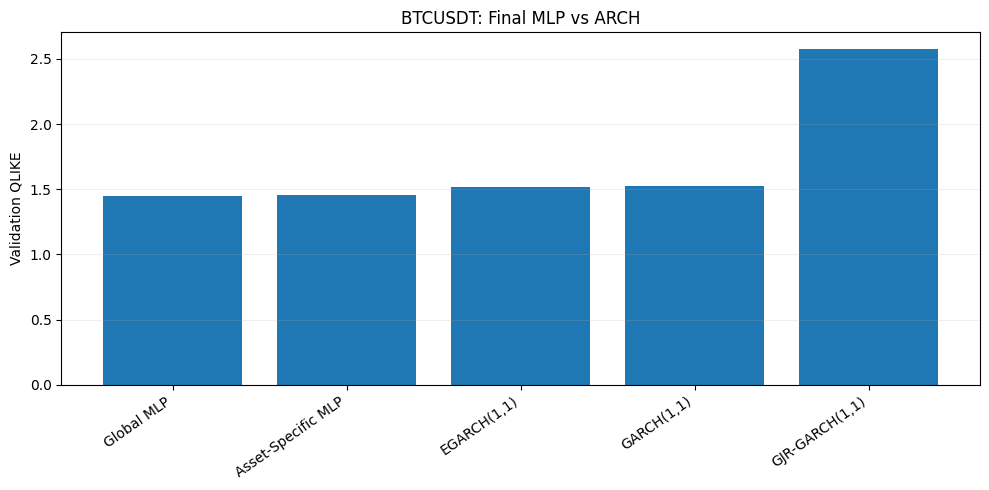

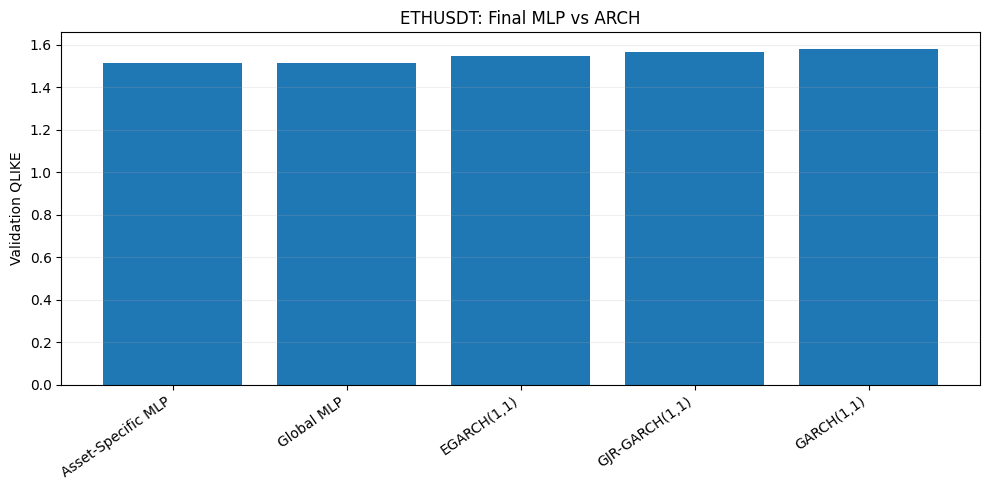

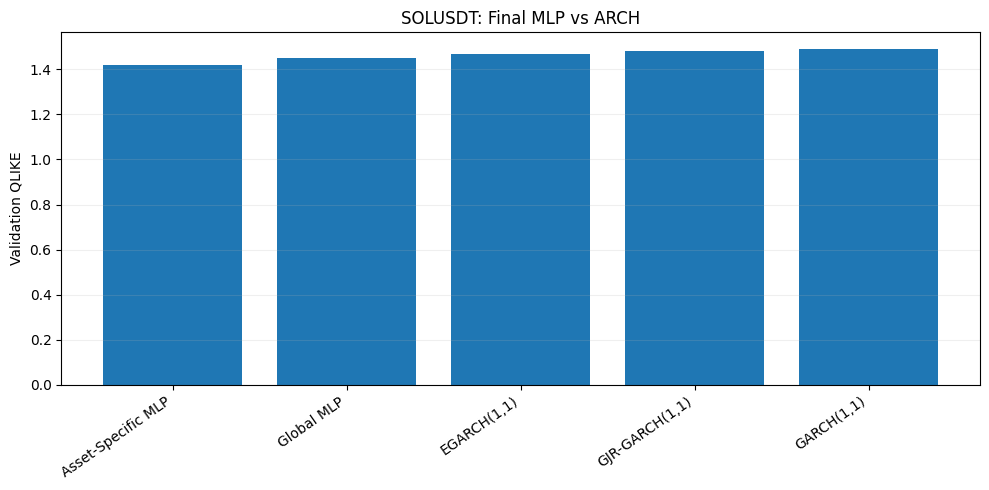

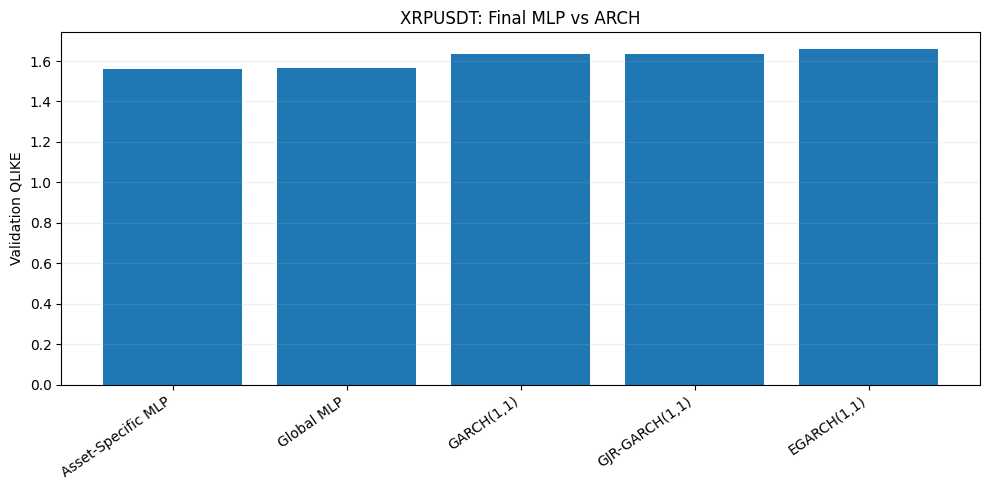

In [27]:
for symbol in SYMBOLS:

    current = (
        fair_validation_comparison_df.loc[
            fair_validation_comparison_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            "qlike"
        )
    )

    plt.figure(
        figsize=(
            10,
            5,
        )
    )

    plt.bar(
        current[
            "model"
        ],
        current[
            "qlike"
        ],
    )

    plt.ylabel(
        "Validation QLIKE"
    )

    plt.title(
        f"{symbol}: Final MLP vs ARCH"
    )

    plt.xticks(
        rotation=35,
        ha="right",
    )

    plt.grid(
        axis="y",
        alpha=0.20,
    )

    plt.tight_layout()

    plt.savefig(
        RESULTS_ROOT
        / (
            f"{symbol}_final_mlp_vs_arch_"
            "validation_qlike.png"
        ),
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

# Part E — Volatility-proxy visualization

The model still forecasts **next-candle variance**.

For visualization only, predicted variance is converted to predicted volatility:

\[
\hat{\sigma}_{t+1}
=
\sqrt{\widehat{RV}_{t+1}}.
\]

It is compared against:

1. the target candle's absolute return \( |r_{t+1}| \);
2. an ex-post rolling standard deviation of returns.

The rolling window is controlled by:

```python
ROLLING_VOLATILITY_WINDOW = "1d"
```

Change it to `"12h"`, `"4h"`, etc. without changing downstream code.

The rolling standard deviation is a visualization / robustness proxy, not the training target.

## 27. Build the dynamic rolling historical-volatility proxy

In [28]:
def strict_rolling_std(
    values,
    times,
    bars,
    ddof=1,
):
    rolling_std = (
        values
        .rolling(
            window=bars,
            min_periods=bars,
        )
        .std(
            ddof=ddof
        )
    )

    rolling_count = (
        values
        .rolling(
            window=bars,
            min_periods=bars,
        )
        .count()
    )

    window_start = (
        times.shift(
            bars - 1
        )
    )

    expected_span = (
        (bars - 1)
        * INTERVAL_DELTA
    )

    exact_span = (
        (
            times
            - window_start
        )
        .eq(
            expected_span
        )
    )

    return rolling_std.where(
        rolling_count.eq(bars)
        & exact_span
    )


ROLLING_VOLATILITY_BARS = (
    duration_to_bars_or_none(
        ROLLING_VOLATILITY_WINDOW
    )
)

if ROLLING_VOLATILITY_BARS is None:
    raise ValueError(
        "ROLLING_VOLATILITY_WINDOW="
        f"{ROLLING_VOLATILITY_WINDOW} cannot be "
        f"represented exactly using {KLINE_INTERVAL} candles."
    )

if ROLLING_VOLATILITY_BARS < 2:
    raise ValueError(
        "Rolling standard deviation requires "
        "at least two candles."
    )

proxy_frames = []

for symbol in SYMBOLS:

    current = (
        features_df.loc[
            features_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            "open_time"
        )
        .copy()
    )

    current[
        "absolute_return_proxy"
    ] = (
        current[
            "return"
        ]
        .abs()
    )

    current[
        "rolling_historical_volatility"
    ] = strict_rolling_std(
        values=current[
            "return"
        ],
        times=current[
            "open_time"
        ],
        bars=ROLLING_VOLATILITY_BARS,
        ddof=1,
    )

    proxy_frames.append(
        current[
            [
                "symbol",
                "open_time",
                "absolute_return_proxy",
                "rolling_historical_volatility",
            ]
        ]
        .rename(
            columns={
                "open_time":
                    "target_open_time"
            }
        )
    )


volatility_proxy_df = pd.concat(
    proxy_frames,
    ignore_index=True,
)

local_plot_df = (
    asset_specific_validation_predictions_df[
        [
            "symbol",
            "target_open_time",
            "predicted_variance",
        ]
    ]
    .rename(
        columns={
            "predicted_variance":
                "asset_specific_predicted_variance"
        }
    )
)

global_plot_df = (
    global_validation_predictions_df[
        [
            "symbol",
            "target_open_time",
            "predicted_variance",
        ]
    ]
    .rename(
        columns={
            "predicted_variance":
                "global_predicted_variance"
        }
    )
)

volatility_plot_data_df = (
    volatility_proxy_df
    .merge(
        local_plot_df,
        on=[
            "symbol",
            "target_open_time",
        ],
        how="inner",
        validate="one_to_one",
    )
    .merge(
        global_plot_df,
        on=[
            "symbol",
            "target_open_time",
        ],
        how="inner",
        validate="one_to_one",
    )
)

volatility_plot_data_df[
    "asset_specific_predicted_volatility"
] = np.sqrt(
    volatility_plot_data_df[
        "asset_specific_predicted_variance"
    ]
)

volatility_plot_data_df[
    "global_predicted_volatility"
] = np.sqrt(
    volatility_plot_data_df[
        "global_predicted_variance"
    ]
)

print(
    "Rolling volatility window:",
    ROLLING_VOLATILITY_WINDOW,
)

print(
    "Bars in rolling window:",
    ROLLING_VOLATILITY_BARS,
)

display(
    volatility_plot_data_df.head()
)

Rolling volatility window: 1d
Bars in rolling window: 96


,symbol,target_open_time,absolute_return_proxy,rolling_historical_volatility,asset_specific_predicted_variance,global_predicted_variance,asset_specific_predicted_volatility,global_predicted_volatility
0,BTCUSDT,2024-08-01 00:00:00+00:00,0.000495,0.002535,0.000009,0.000008,0.003026,0.002765
1,BTCUSDT,2024-08-01 00:15:00+00:00,0.001455,0.002534,0.000009,0.000007,0.003000,0.002624
2,BTCUSDT,2024-08-01 00:30:00+00:00,0.001429,0.002511,0.000007,0.000012,0.002726,0.003498
3,BTCUSDT,2024-08-01 00:45:00+00:00,0.000193,0.002505,0.000006,0.000006,0.002384,0.002350
4,BTCUSDT,2024-08-01 01:00:00+00:00,0.000215,0.002504,0.000006,0.000009,0.002524,0.002927


## 28. Forecasts versus absolute returns

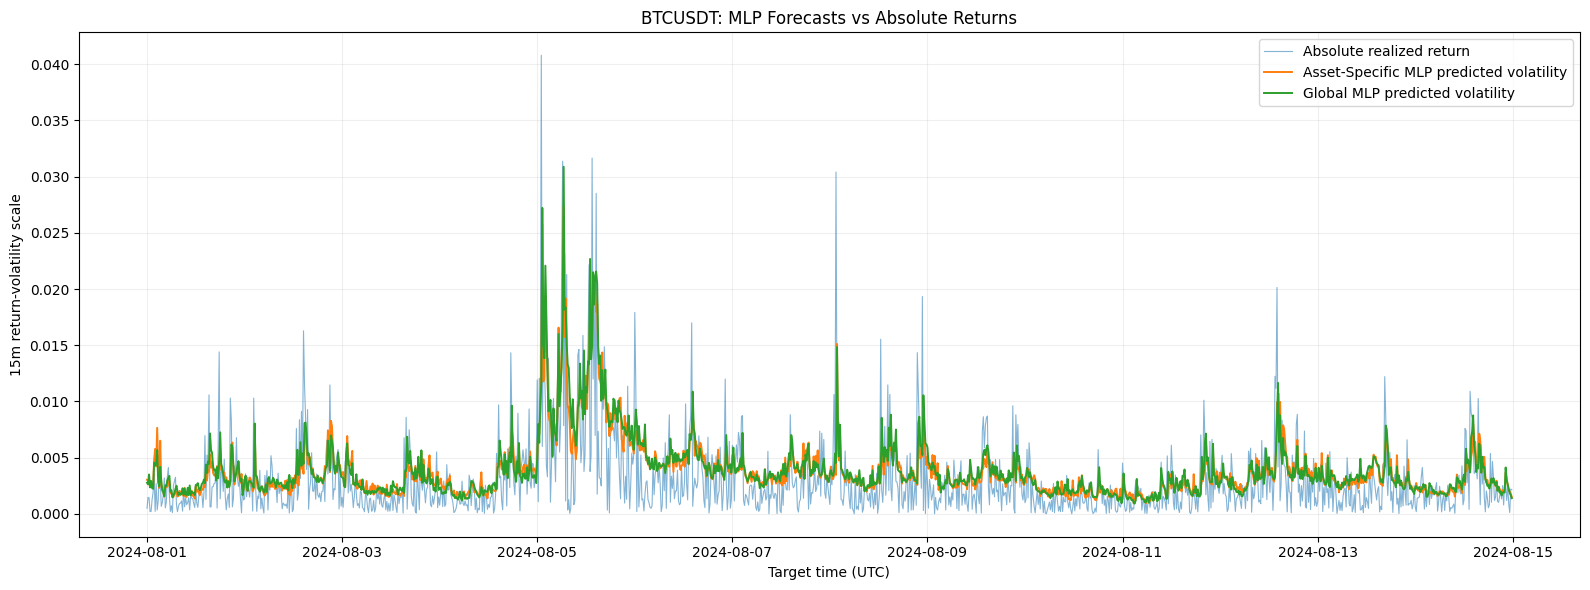

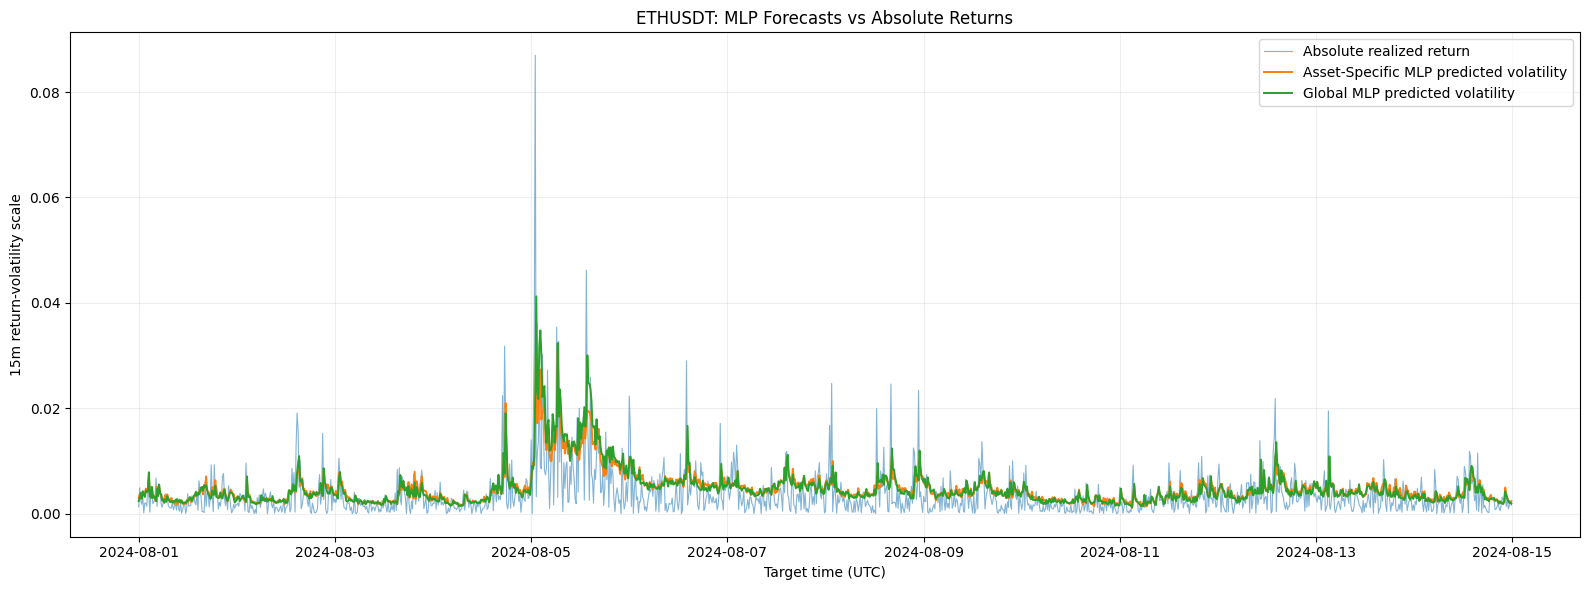

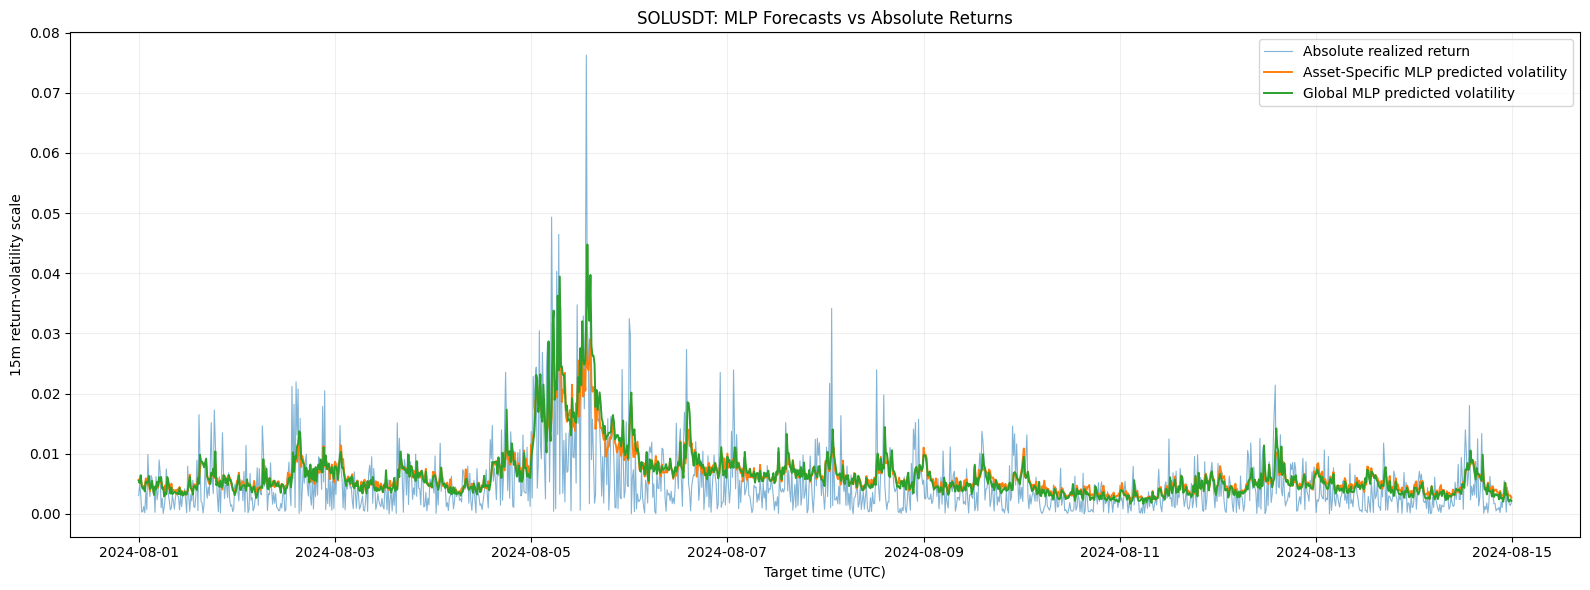

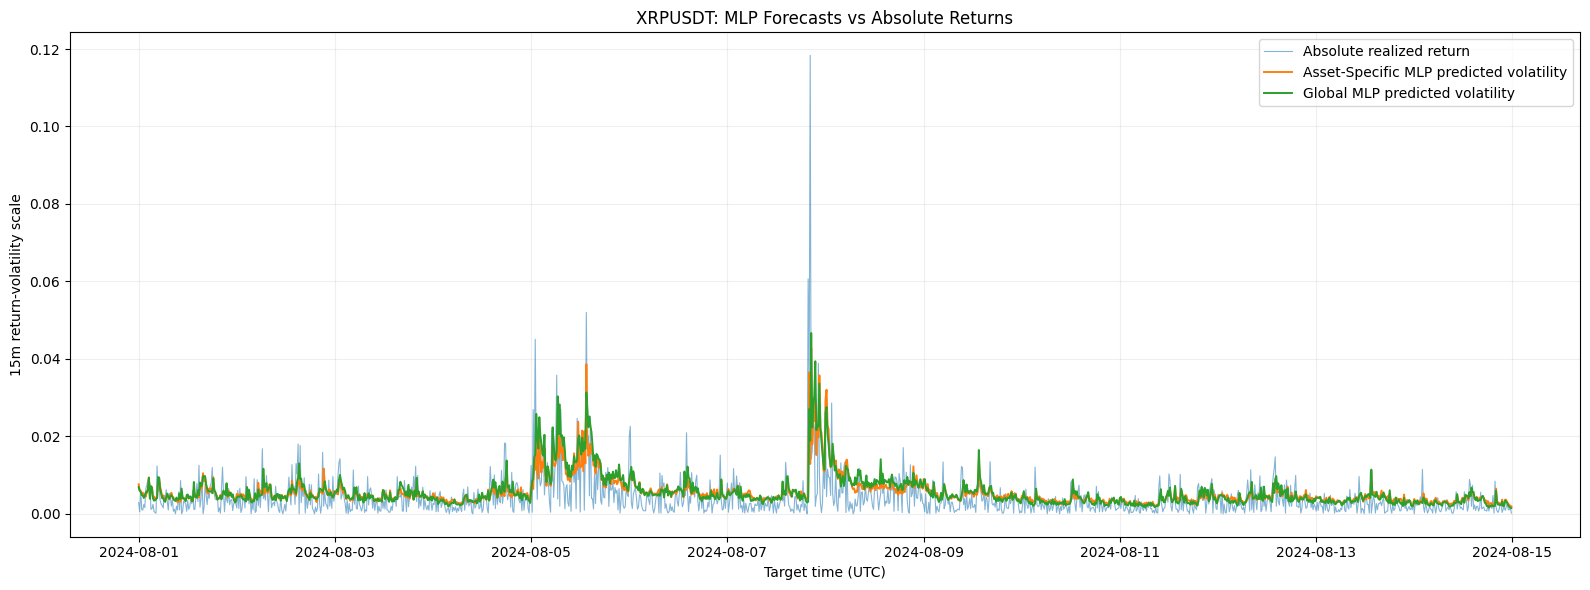

In [29]:
plot_start = (
    VALIDATION_START
    if PLOT_START is None
    else pd.Timestamp(
        PLOT_START
    )
)

if plot_start.tzinfo is None:
    plot_start = (
        plot_start
        .tz_localize("UTC")
    )
else:
    plot_start = (
        plot_start
        .tz_convert("UTC")
    )

plot_end = (
    plot_start
    + pd.Timedelta(
        PLOT_WINDOW_DURATION
    )
)

for symbol in SYMBOLS:

    current = (
        volatility_plot_data_df.loc[
            volatility_plot_data_df[
                "symbol"
            ].eq(symbol)
            & volatility_plot_data_df[
                "target_open_time"
            ].ge(plot_start)
            & volatility_plot_data_df[
                "target_open_time"
            ].lt(plot_end)
        ]
        .sort_values(
            "target_open_time"
        )
    )

    if current.empty:
        raise ValueError(
            f"{symbol}: selected plot window has no data."
        )

    plt.figure(
        figsize=(
            16,
            6,
        )
    )

    plt.plot(
        current[
            "target_open_time"
        ],
        current[
            "absolute_return_proxy"
        ],
        label="Absolute realized return",
        linewidth=0.8,
        alpha=0.55,
    )

    plt.plot(
        current[
            "target_open_time"
        ],
        current[
            "asset_specific_predicted_volatility"
        ],
        label="Asset-Specific MLP predicted volatility",
        linewidth=1.4,
    )

    plt.plot(
        current[
            "target_open_time"
        ],
        current[
            "global_predicted_volatility"
        ],
        label="Global MLP predicted volatility",
        linewidth=1.4,
    )

    plt.xlabel(
        "Target time (UTC)"
    )

    plt.ylabel(
        f"{KLINE_INTERVAL} return-volatility scale"
    )

    plt.title(
        f"{symbol}: MLP Forecasts vs Absolute Returns"
    )

    plt.legend()
    plt.grid(alpha=0.20)
    plt.tight_layout()

    plt.savefig(
        RESULTS_ROOT
        / (
            f"{symbol}_forecast_vs_absolute_return.png"
        ),
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

## 29. Forecasts versus rolling historical volatility

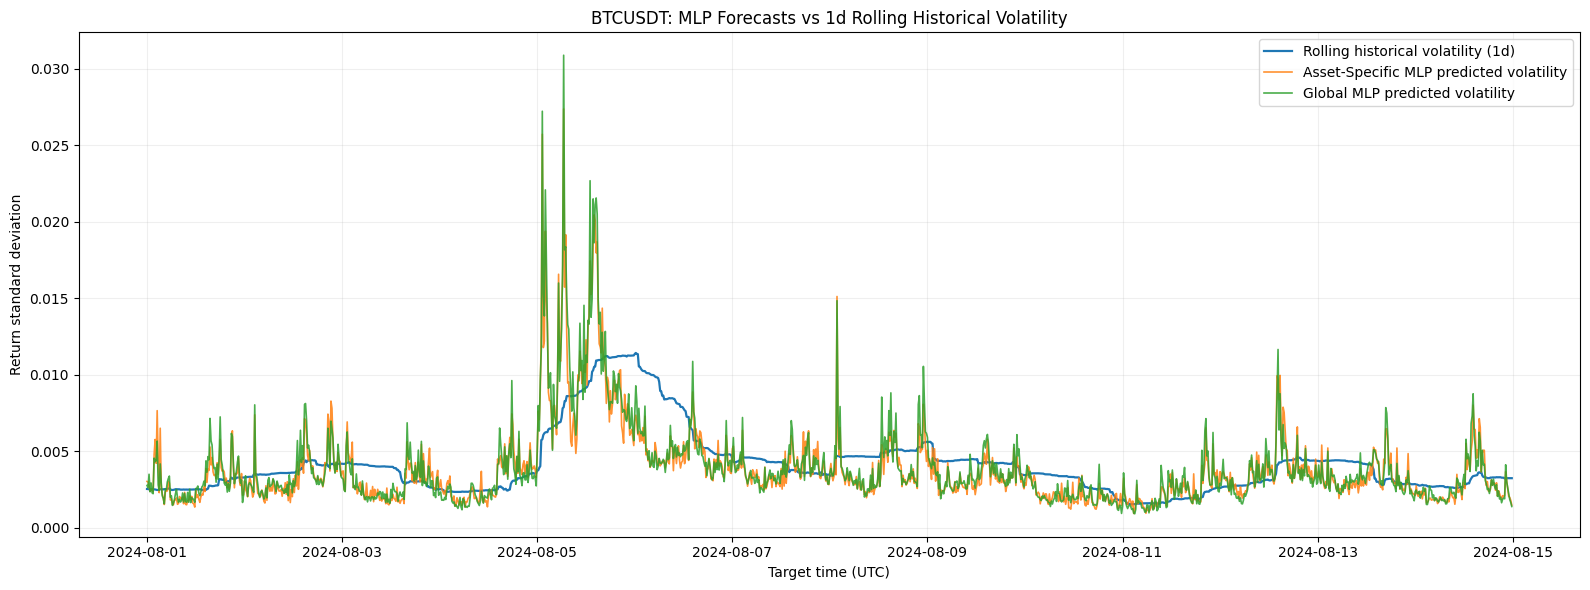

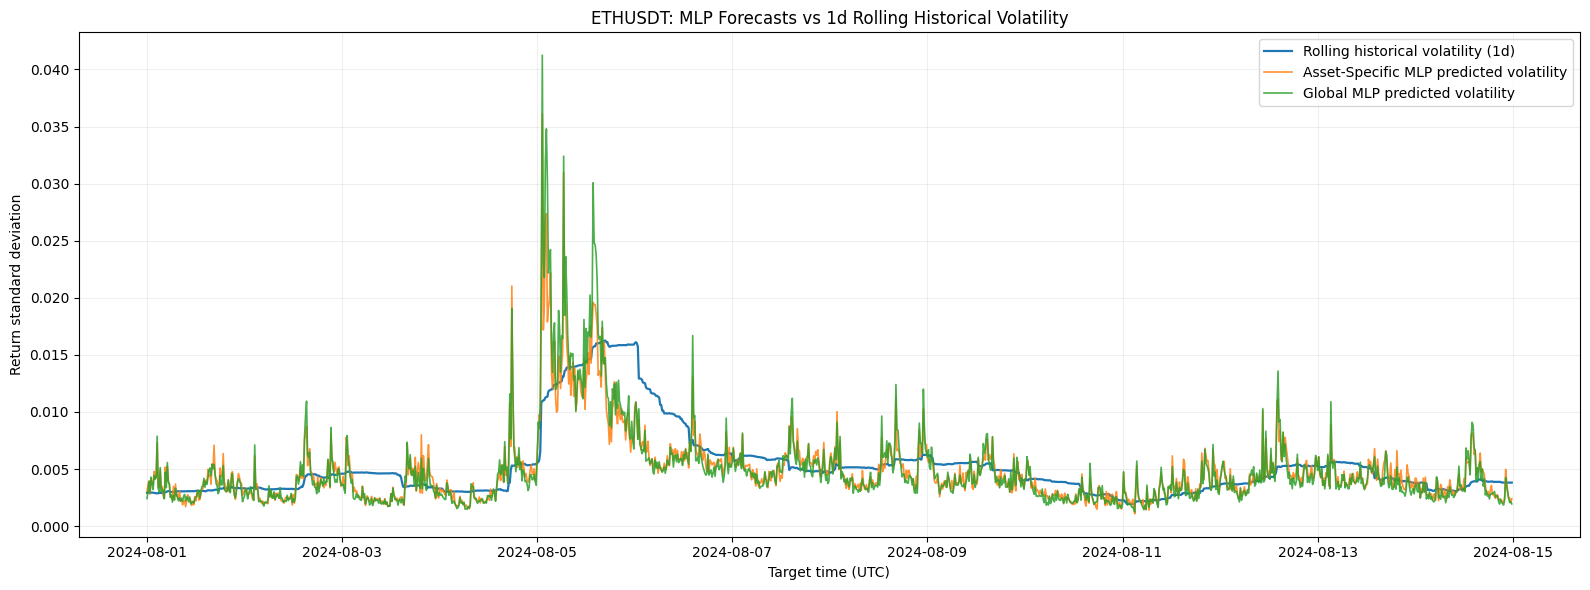

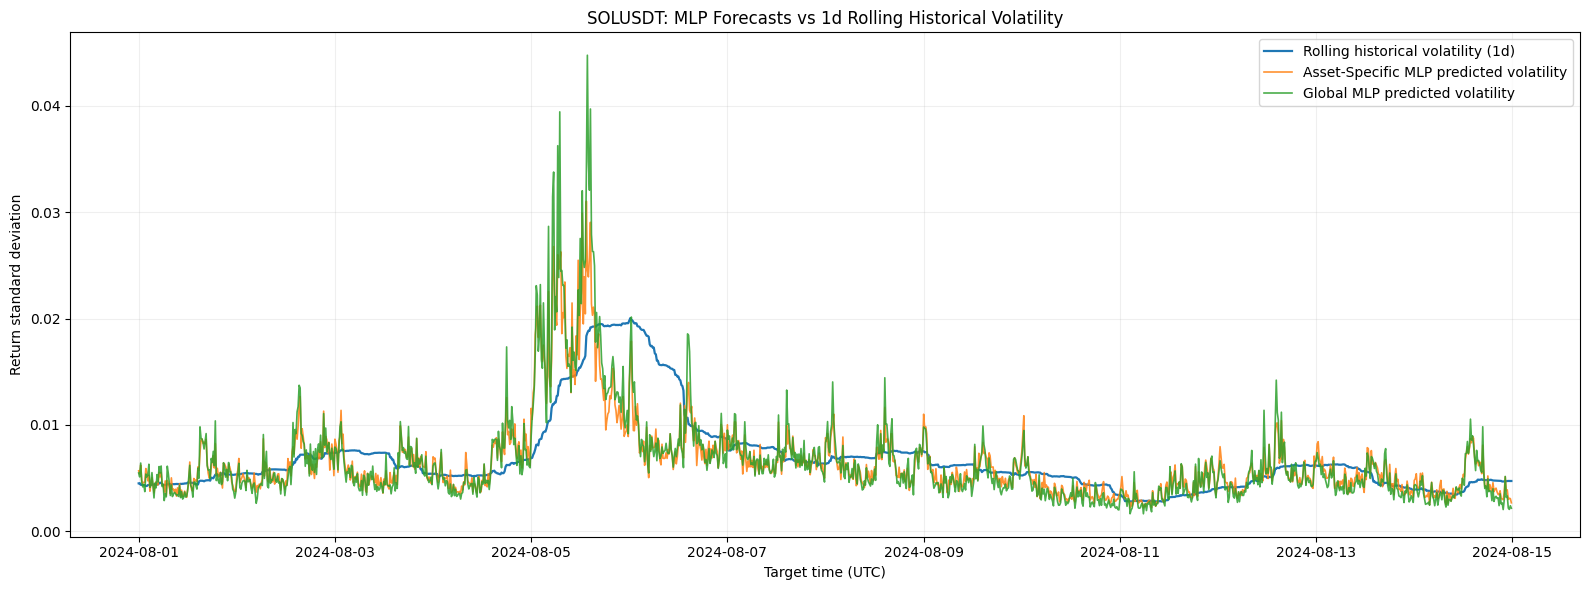

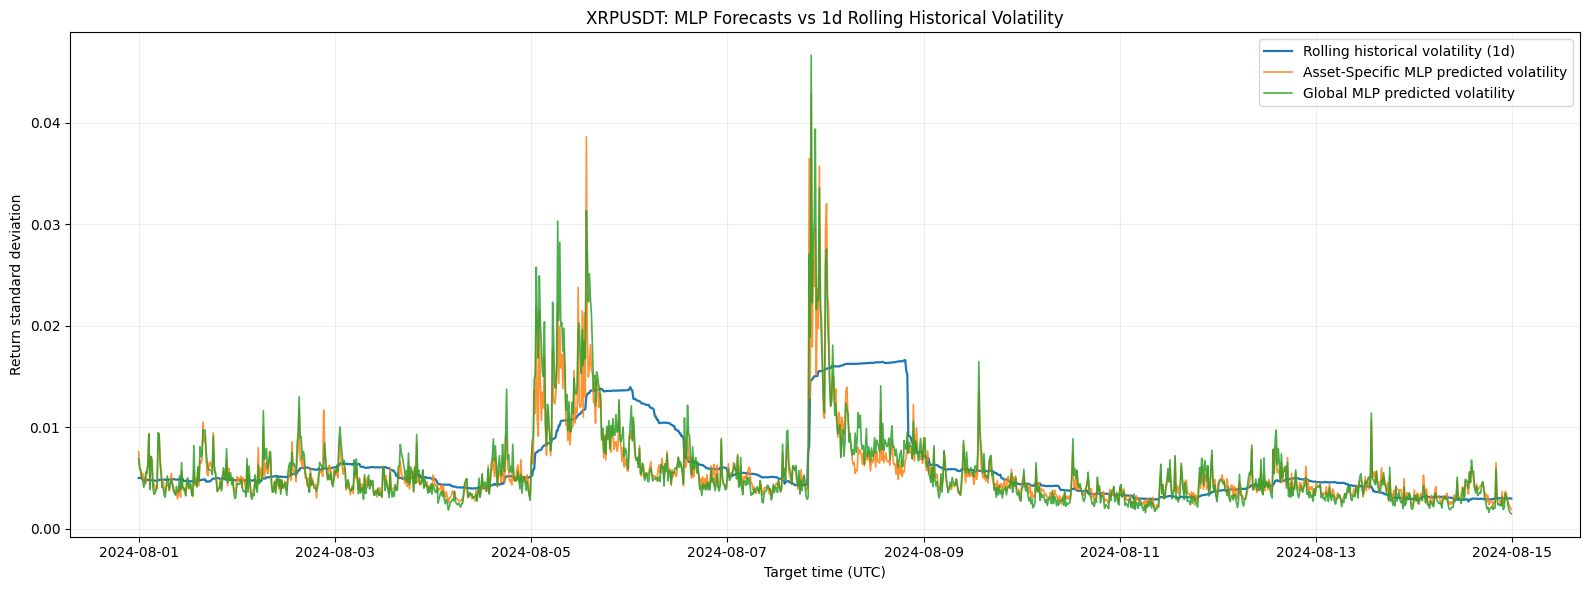

In [30]:
for symbol in SYMBOLS:

    current = (
        volatility_plot_data_df.loc[
            volatility_plot_data_df[
                "symbol"
            ].eq(symbol)
            & volatility_plot_data_df[
                "target_open_time"
            ].ge(plot_start)
            & volatility_plot_data_df[
                "target_open_time"
            ].lt(plot_end)
            & volatility_plot_data_df[
                "rolling_historical_volatility"
            ].notna()
        ]
        .sort_values(
            "target_open_time"
        )
    )

    if current.empty:
        raise ValueError(
            f"{symbol}: no rolling-volatility values "
            "inside the selected plot window."
        )

    plt.figure(
        figsize=(
            16,
            6,
        )
    )

    plt.plot(
        current[
            "target_open_time"
        ],
        current[
            "rolling_historical_volatility"
        ],
        label=(
            "Rolling historical volatility "
            f"({ROLLING_VOLATILITY_WINDOW})"
        ),
        linewidth=1.6,
    )

    plt.plot(
        current[
            "target_open_time"
        ],
        current[
            "asset_specific_predicted_volatility"
        ],
        label="Asset-Specific MLP predicted volatility",
        linewidth=1.2,
        alpha=0.85,
    )

    plt.plot(
        current[
            "target_open_time"
        ],
        current[
            "global_predicted_volatility"
        ],
        label="Global MLP predicted volatility",
        linewidth=1.2,
        alpha=0.85,
    )

    plt.xlabel(
        "Target time (UTC)"
    )

    plt.ylabel(
        "Return standard deviation"
    )

    plt.title(
        f"{symbol}: MLP Forecasts vs "
        f"{ROLLING_VOLATILITY_WINDOW} "
        "Rolling Historical Volatility"
    )

    plt.legend()
    plt.grid(alpha=0.20)
    plt.tight_layout()

    plt.savefig(
        RESULTS_ROOT
        / (
            f"{symbol}_forecast_vs_rolling_volatility_"
            f"{duration_tag(ROLLING_VOLATILITY_WINDOW)}.png"
        ),
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

# Part F — Save final MLP outputs

## 30. Save metrics, predictions, plot data and configuration

In [31]:
INNER_METRICS_PATH = (
    INNER_RESULTS_ROOT
    / "asset_specific_inner_tuning_metrics.csv"
)

INNER_HISTORIES_PATH = (
    INNER_RESULTS_ROOT
    / "asset_specific_inner_training_histories.csv"
)

INNER_CONFIG_SUMMARY_PATH = (
    INNER_RESULTS_ROOT
    / "asset_specific_inner_configuration_summary.csv"
)

GLOBAL_INNER_HISTORY_PATH = (
    INNER_RESULTS_ROOT
    / "global_inner_training_history.csv"
)

GLOBAL_FINAL_HISTORY_PATH = (
    RESULTS_ROOT
    / "global_final_train_history.csv"
)

ASSET_SPECIFIC_METRICS_PATH = (
    RESULTS_ROOT
    / "asset_specific_mlp_validation_metrics.csv"
)

ASSET_SPECIFIC_PREDICTIONS_PATH = (
    RESULTS_ROOT
    / "asset_specific_mlp_validation_predictions.parquet"
)

ASSET_SPECIFIC_TRAINING_PATH = (
    RESULTS_ROOT
    / "asset_specific_mlp_training_summary.csv"
)

GLOBAL_METRICS_PATH = (
    RESULTS_ROOT
    / "global_mlp_validation_metrics.csv"
)

GLOBAL_PREDICTIONS_PATH = (
    RESULTS_ROOT
    / "global_mlp_validation_predictions.parquet"
)

FAIR_COMPARISON_PATH = (
    RESULTS_ROOT
    / "final_mlp_vs_arch_validation_comparison.csv"
)

MLP_VS_ARCH_SUMMARY_PATH = (
    RESULTS_ROOT
    / "final_mlp_vs_best_arch_summary.csv"
)

COMPARISON_DATES_PATH = (
    RESULTS_ROOT
    / "fair_validation_date_coverage.csv"
)

VOLATILITY_PLOT_DATA_PATH = (
    RESULTS_ROOT
    / (
        "validation_volatility_plot_data_"
        f"{duration_tag(ROLLING_VOLATILITY_WINDOW)}.parquet"
    )
)

CONFIG_PATH = (
    RESULTS_ROOT
    / "final_mlp_configuration.json"
)


inner_metrics_df.to_csv(
    INNER_METRICS_PATH,
    index=False,
)

inner_histories_df.to_csv(
    INNER_HISTORIES_PATH,
    index=False,
)

inner_config_summary_df.to_csv(
    INNER_CONFIG_SUMMARY_PATH,
    index=False,
)

global_inner_history_df.to_csv(
    GLOBAL_INNER_HISTORY_PATH,
    index=False,
)

global_final_history_df.to_csv(
    GLOBAL_FINAL_HISTORY_PATH,
    index=False,
)

asset_specific_validation_metrics_df.to_csv(
    ASSET_SPECIFIC_METRICS_PATH,
    index=False,
)

asset_specific_validation_predictions_df.to_parquet(
    ASSET_SPECIFIC_PREDICTIONS_PATH,
    index=False,
)

final_training_summary_df.to_csv(
    ASSET_SPECIFIC_TRAINING_PATH,
    index=False,
)

global_validation_metrics_df.to_csv(
    GLOBAL_METRICS_PATH,
    index=False,
)

global_validation_predictions_df.to_parquet(
    GLOBAL_PREDICTIONS_PATH,
    index=False,
)

fair_validation_comparison_df.to_csv(
    FAIR_COMPARISON_PATH,
    index=False,
)

mlp_vs_arch_summary_df.to_csv(
    MLP_VS_ARCH_SUMMARY_PATH,
    index=False,
)

comparison_dates_df.to_csv(
    COMPARISON_DATES_PATH,
    index=False,
)

volatility_plot_data_df.to_parquet(
    VOLATILITY_PLOT_DATA_PATH,
    index=False,
)


configuration = {
    "created_at_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "model_family":
        "Final Enhanced MLP",

    "kline_interval":
        KLINE_INTERVAL,

    "interval_minutes":
        INTERVAL_MINUTES,

    "forecast_horizon":
        "one_candle_ahead",

    "target":
        "next_candle_squared_log_return",

    "training_target":
        "deseasonalized_next_candle_variance_level",

    "loss":
        "gaussian_variance_quasi_likelihood_qlike_aligned",

    "inner_tuning": {
        "duration":
            str(
                INNER_TUNING_DURATION
            ),

        "start_utc":
            INNER_TUNE_START.isoformat(),

        "official_validation_used_for_selection":
            False,
    },

    "selected_feature_set":
        SELECTED_FEATURE_SET,

    "selected_feature_columns":
        SELECTED_FEATURE_COLUMNS,

    "selected_learning_rate":
        SELECTED_LEARNING_RATE,

    "asset_specific_selected_epoch_by_asset":
        SELECTED_EPOCH_BY_ASSET,

    "global_selected_epochs":
        GLOBAL_FINAL_EPOCHS,

    "global_asset_order":
        ASSET_ORDER,

    "global_asset_balanced_sample_weights":
        True,

    "global_scaling":
        "per_asset_train_only_standard_scaler",

    "dynamic_horizons": {
        "rv_state_bars":
            RV_STATE_BARS,

        "range_bars":
            RANGE_BARS,

        "semivariance_bars":
            SEMIVAR_BARS,

        "activity_bars":
            ACTIVITY_BARS,

        "lag_bar_specs":
            LAG_BAR_SPECS,
    },

    "visualization": {
        "rolling_volatility_window":
            ROLLING_VOLATILITY_WINDOW,

        "rolling_volatility_bars":
            ROLLING_VOLATILITY_BARS,

        "plot_window_duration":
            PLOT_WINDOW_DURATION,

        "rolling_std_ddof":
            1,

        "rolling_volatility_is_training_target":
            False,
    },

    "global_model_path":
        str(
            GLOBAL_MODEL_PATH
        ),

    "global_scalers_path":
        str(
            GLOBAL_SCALERS_PATH
        ),

    "enhanced_feature_artifact":
        str(
            ENHANCED_FEATURES_PATH
        ),

    "test_evaluated":
        False,
}


with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        configuration,
        file,
        indent=2,
        ensure_ascii=False,
    )


print(
    "Saved final MLP outputs:"
)

for path in [
    INNER_METRICS_PATH,
    INNER_HISTORIES_PATH,
    INNER_CONFIG_SUMMARY_PATH,
    GLOBAL_INNER_HISTORY_PATH,
    GLOBAL_FINAL_HISTORY_PATH,
    ASSET_SPECIFIC_METRICS_PATH,
    ASSET_SPECIFIC_PREDICTIONS_PATH,
    ASSET_SPECIFIC_TRAINING_PATH,
    GLOBAL_METRICS_PATH,
    GLOBAL_PREDICTIONS_PATH,
    FAIR_COMPARISON_PATH,
    MLP_VS_ARCH_SUMMARY_PATH,
    COMPARISON_DATES_PATH,
    VOLATILITY_PLOT_DATA_PATH,
    CONFIG_PATH,
]:
    print(
        " -",
        path,
    )

Saved final MLP outputs:
 - /content/drive/MyDrive/Quant Research/15min/results/15m/MLP_FINAL/inner_tuning/asset_specific_inner_tuning_metrics.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/MLP_FINAL/inner_tuning/asset_specific_inner_training_histories.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/MLP_FINAL/inner_tuning/asset_specific_inner_configuration_summary.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/MLP_FINAL/inner_tuning/global_inner_training_history.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/MLP_FINAL/global_final_train_history.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/MLP_FINAL/asset_specific_mlp_validation_metrics.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/MLP_FINAL/asset_specific_mlp_validation_predictions.parquet
 - /content/drive/MyDrive/Quant Research/15min/results/15m/MLP_FINAL/asset_specific_mlp_training_summary.csv
 - /content/drive/MyDrive/Quant Research/15

## 31. Final end-to-end QC

In [32]:
# Test remains untouched.
for prediction_df in [
    asset_specific_validation_predictions_df,
    global_validation_predictions_df,
]:

    assert (
        prediction_df[
            "target_open_time"
        ]
        .ge(
            VALIDATION_START
        )
        .all()
    )

    assert (
        prediction_df[
            "target_open_time"
        ]
        .lt(
            TEST_START
        )
        .all()
    )


# Every asset is represented.
assert (
    asset_specific_validation_metrics_df[
        "symbol"
    ]
    .nunique()
    == len(SYMBOLS)
)

assert (
    global_validation_metrics_df[
        "symbol"
    ]
    .nunique()
    == len(SYMBOLS)
)


# Finite positive forecasts.
for prediction_df in [
    asset_specific_validation_predictions_df,
    global_validation_predictions_df,
]:

    assert np.isfinite(
        prediction_df[
            "predicted_variance"
        ]
        .to_numpy(
            dtype=float
        )
    ).all()

    assert (
        prediction_df[
            "predicted_variance"
        ]
        .gt(0)
        .all()
    )


# Finite metrics.
for metric_df in [
    asset_specific_validation_metrics_df,
    global_validation_metrics_df,
]:

    assert np.isfinite(
        metric_df[
            [
                "mae",
                "rmse",
                "qlike",
            ]
        ]
        .to_numpy(
            dtype=float
        )
    ).all()

    assert (
        metric_df[
            "qlike"
        ]
        .ge(
            -1e-12
        )
        .all()
    )


# Fair comparison: exactly two MLP variants + three ARCH models.
for symbol in SYMBOLS:

    current = (
        fair_validation_comparison_df.loc[
            fair_validation_comparison_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    assert (
        current[
            "model"
        ]
        .eq(
            "Asset-Specific MLP"
        )
        .sum()
        == 1
    )

    assert (
        current[
            "model"
        ]
        .eq(
            "Global MLP"
        )
        .sum()
        == 1
    )

    assert (
        current[
            "model_family"
        ]
        .eq("ARCH")
        .sum()
        == 3
    )


# Model artifacts exist.
assert GLOBAL_MODEL_PATH.exists()
assert GLOBAL_SCALERS_PATH.exists()

for symbol in SYMBOLS:

    asset_model_path = (
        MODEL_ROOT
        / symbol
        / "final_asset_specific_mlp.keras"
    )

    asset_scaler_path = (
        ARTIFACT_ROOT
        / symbol
        / "feature_scaler.joblib"
    )

    assert asset_model_path.exists()
    assert asset_scaler_path.exists()


# Plot data is internally valid.
assert (
    ROLLING_VOLATILITY_BARS
    >= 2
)

assert np.isfinite(
    volatility_plot_data_df[
        [
            "asset_specific_predicted_volatility",
            "global_predicted_volatility",
        ]
    ]
    .to_numpy(
        dtype=float
    )
).all()


# Saved prediction artifacts reload.
reloaded_asset_predictions = (
    pd.read_parquet(
        ASSET_SPECIFIC_PREDICTIONS_PATH
    )
)

reloaded_global_predictions = (
    pd.read_parquet(
        GLOBAL_PREDICTIONS_PATH
    )
)

assert (
    len(
        reloaded_asset_predictions
    )
    == len(
        asset_specific_validation_predictions_df
    )
)

assert (
    len(
        reloaded_global_predictions
    )
    == len(
        global_validation_predictions_df
    )
)


print(
    "ALL FINAL INTRADAY MLP "
    "QC CHECKS PASSED."
)

print(
    "\nSelected feature set:",
    SELECTED_FEATURE_SET,
)

print(
    "Selected learning rate:",
    SELECTED_LEARNING_RATE,
)

print(
    "Global final epochs:",
    GLOBAL_FINAL_EPOCHS,
)

print(
    "Rolling volatility proxy:",
    ROLLING_VOLATILITY_WINDOW,
    "=",
    ROLLING_VOLATILITY_BARS,
    "bars",
)

print(
    "\nFinal Validation comparison:"
)

display(
    fair_validation_comparison_df
    .sort_values(
        [
            "symbol",
            "qlike",
        ]
    )
    .style.format({
        "mae":
            "{:.10f}",
        "rmse":
            "{:.10f}",
        "qlike":
            "{:.6f}",
    })
)

print(
    "\nTest period remains untouched."
)

ALL FINAL INTRADAY MLP QC CHECKS PASSED.

Selected feature set: FULL_ACTIVITY
Selected learning rate: 0.0003
Global final epochs: 7
Rolling volatility proxy: 1d = 96 bars

Final Validation comparison:


,symbol,model,model_family,observations,mae,rmse,qlike,qlike_rank
0,BTCUSDT,Global MLP,Deep Learning,35040,0.0000077988,0.0000306647,1.449854,1
1,BTCUSDT,Asset-Specific MLP,Deep Learning,35040,0.0000074116,0.0000297903,1.451999,2
2,BTCUSDT,"EGARCH(1,1)",ARCH,35040,0.0000083355,0.0000300130,1.515321,3
3,BTCUSDT,"GARCH(1,1)",ARCH,35040,0.0000083570,0.0000304362,1.526979,4
4,BTCUSDT,"GJR-GARCH(1,1)",ARCH,35040,0.0000276936,0.0000385086,2.575465,5
5,ETHUSDT,Asset-Specific MLP,Deep Learning,35040,0.0000168370,0.0000939594,1.511114,1
6,ETHUSDT,Global MLP,Deep Learning,35040,0.0000167457,0.0000956796,1.513227,2
7,ETHUSDT,"EGARCH(1,1)",ARCH,35040,0.0000176928,0.0000941864,1.548225,3
8,ETHUSDT,"GJR-GARCH(1,1)",ARCH,35040,0.0000180804,0.0000957609,1.564462,4
9,ETHUSDT,"GARCH(1,1)",ARCH,35040,0.0000181966,0.0000949754,1.578670,5



Test period remains untouched.


# Final MLP methodology

The final MLP stage contains two neural forecasts:

### Asset-Specific MLP
Each asset learns its own nonlinear mapping from the enhanced volatility-state vector to next-candle variance.

### Global MLP
A single pooled model learns across BTC, ETH, SOL and XRP while retaining per-asset Train-only scaling, explicit asset identity and asset-balanced optimization weights.

### Evaluation
Both models forecast the same next-candle squared-return variance and are compared with ARCH on identical Validation timestamps using QLIKE, MAE and RMSE.

### Visual diagnostics
Predicted standard deviation is visualized against the target absolute return and a dynamically configurable rolling historical standard deviation.

### Test
The held-out Test period remains sealed.